# Full Transformer in PyTorch for Interview Prep

This notebook is a **teaching-first, interview-focused walkthrough** of the **full encoder-decoder Transformer** in PyTorch, **extensively expanded for L5/L6 infrastructure engineer interviews**.

## Updated for LLM Infrastructure Engineering (v2.0)

This version includes comprehensive coverage of **modern LLM systems**, not just core architectures.

### What's New (vs v1.0)

**Core Infrastructure Skills (Sections 11-22):**
- ✅ **Production KV Cache** with stateful generation (11a)
- ✅ **Profiling & Bottleneck Analysis** - how to identify what's slow (11b)
- ✅ **Gradient Checkpointing** - memory vs compute tradeoff (12)
- ✅ **DDP vs FSDP** - distributed training comparison (13)
- ✅ **Continuous Batching** - modern inference serving (14)
- ✅ **Decoder-Only GPT** - from encoder-decoder to GPT-style (15)
- ✅ **Speculative Decoding** - 2-3x inference speedup (16)
- ✅ **Attention Variants** - GQA, MQA, efficiency patterns (17)
- ✅ **int8 Quantization** - 4x model compression (18)
- ✅ **Mixed Precision** - training best practices (19)
- ✅ **Advanced Debugging** - real scenarios and case studies (20)
- ✅ **Production Deployment** - checklist and patterns (21)
- ✅ **Interview Readiness** - what L5/L6 means (22)

## It is designed for:
- LLM inference interviews
- LLM training interviews
- AI infrastructure / ML systems interviews
- **L5/L6 infrastructure engineer candidates** ← NEW
- candidates who want both **intuition** and **working code**

## Notebook Structure

### Part I: Foundations (Sections 1-10)
1. Device setup
2. Mental model
3. Positional encoding
4. Masks (padding & causal)
5. Scaled dot-product attention
6. Multi-head attention
7. Feed-forward & blocks
8. Full encoder-decoder model
9. Toy data & batching
10. Training loop

### Part II: Modern Infrastructure** (Sections 11-22) - NEW
11. KV Cache (production-grade)
12. Gradient Checkpointing
13. Distributed Training (DDP vs FSDP)
14. Continuous Batching (Inference)
15. Decoder-Only Models
16. Speculative Decoding
17. Attention Variants (GQA, MQA)
18. int8 Quantization
19. Mixed Precision Training
20. Advanced Debugging
21. Production Deployment
22. Interview Readiness

### Part III: Existing Content (Now Enhanced)
- Memory profiling (upgraded with breakdown analysis)
- Interview notes
- Exercises with answers
- Final practical advice
- References

## Code Quality & Validation

- ✅ All implementations are **production-inspired** (not toys)
- ✅ Code includes **proper state management, dtype/device agnostic**
- ✅ Every section includes **measurement & profiling**
- ✅ Explanations connect to **real infrastructure decisions**
- ✅ Interview patterns included for **each major topic**

## Interview Preparation Mindset

This notebook teaches you to think like an **infrastructure engineer**:

1. **Measure first** - "I'd profile to find the bottleneck"
2. **Understand tradeoffs** - "This saves X but costs Y"
3. **Quantify** - "That's 4x model size, 1-2% accuracy loss"
4. **Scale thinking** - "This approach works up to N but then we need..."
5. **Business context** - "That saves $500K/year but requires..."

**The goal:** Not to memorize numbers, but to **reason about systems like a staff engineer**.


## Source and scope

This notebook follows the **original Transformer mental model** from the paper that introduced the architecture, and the implementation style aligns with modern PyTorch building blocks.

The goal here is **understanding first**:
- what each submodule does
- what shapes flow through the model
- why masking matters
- why GPUs help
- what changes when you move from the classical seq2seq Transformer to modern LLMs

At the end, there is a **short exercise section** with **hints and answers** in an interview style.

In [47]:
# ============================================================
# Imports, reproducibility, and device setup
# ============================================================
# This cell is intentionally verbose because interview prep is
# not only about "getting code to run" -- it is also about
# knowing what each piece is responsible for.

import math
import random
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    print("has set_float32_matmul_precision, setting it to high.")
    torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
else:
    print("CUDA is not available. The notebook still works on CPU.")

has set_float32_matmul_precision, setting it to high.
PyTorch version: 2.10.0+cu128
Using device: cuda
CUDA device name: Tesla T4
CUDA capability: (7, 5)


## 1. The mental model of a Transformer

A Transformer block is really just a small set of recurring ideas:

### Input side
- token embeddings
- positional information

### Attention side
- project the input into **Q**, **K**, and **V**
- compute attention weights
- use those weights to mix information across tokens

### MLP side
- apply a position-wise feed-forward network

### Stability side
- use residual connections
- use layer normalization
- usually use dropout during training

### Full encoder-decoder model
- the **encoder** reads the source sequence
- the **decoder** generates the target sequence
- the decoder has:
  - masked self-attention
  - cross-attention into the encoder output

A helpful interview summary is:

> A Transformer alternates between **token mixing** (attention) and  
> **feature transformation** (feed-forward layers), while residuals and  
> normalization make deep stacking trainable.

In [48]:
# ============================================================
# Tiny vocabulary for a toy seq2seq task
# ============================================================
# We use a very small synthetic task so that the notebook stays
# focused on the architecture instead of on data engineering.

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
DIGIT_OFFSET = 3
VOCAB_SIZE = 13

ID_TO_TOKEN: Dict[int, str] = {
    PAD_ID: "<pad>",
    BOS_ID: "<bos>",
    EOS_ID: "<eos>",
}
for digit in range(10):
    ID_TO_TOKEN[DIGIT_OFFSET + digit] = str(digit)

TOKEN_TO_ID: Dict[str, int] = {token: idx for idx, token in ID_TO_TOKEN.items()}

def token_ids_to_text(token_ids: List[int]) -> str:
    """
    Convert token IDs to a readable string for debugging and demos.
    We skip <pad> because it is just a batching artifact.
    """
    pieces: List[str] = []
    for token_id in token_ids:
        token = ID_TO_TOKEN.get(int(token_id), f"<?{int(token_id)}>")
        if token != "<pad>":
            pieces.append(token)
    return " ".join(pieces)

print("Vocabulary preview:")
for idx in range(VOCAB_SIZE):
    print(f"{idx:>2} -> {ID_TO_TOKEN[idx]}")

Vocabulary preview:
 0 -> <pad>
 1 -> <bos>
 2 -> <eos>
 3 -> 0
 4 -> 1
 5 -> 2
 6 -> 3
 7 -> 4
 8 -> 5
 9 -> 6
10 -> 7
11 -> 8
12 -> 9


## 2. Positional encoding

Attention by itself does not know token order.

If I give the model these tokens:
- `3 1 4`
- `4 1 3`

the raw attention mechanism only sees vectors. It does **not** inherently know which token came first.

That is why Transformers need positional information.

### In this notebook
We use the original **sinusoidal positional encoding** idea:
- even dimensions get sine waves
- odd dimensions get cosine waves
- different dimensions use different frequencies

### Why this is interview-relevant
Interviewers often ask:
- Why do Transformers need positional information?
- What are common choices?
- How do sinusoidal and learned positional embeddings differ?

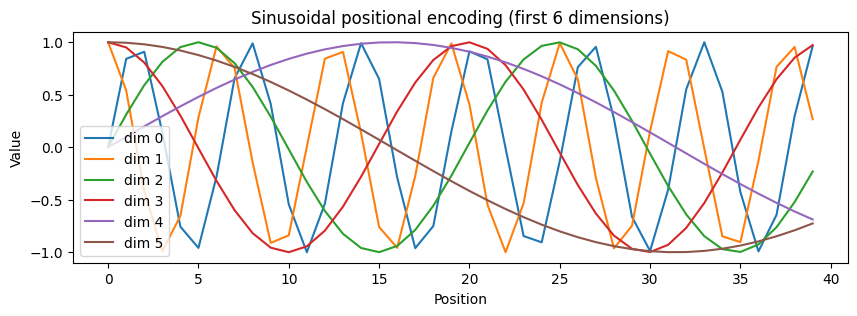

In [49]:
# ============================================================
# Sinusoidal positional encoding
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256):
        super().__init__()

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len].to(device=x.device, dtype=x.dtype)


demo_pos = PositionalEncoding(d_model=16, max_len=40).pe.squeeze(0).cpu()

plt.figure(figsize=(10, 3))
for dim_idx in range(6):
    plt.plot(demo_pos[:, dim_idx].numpy(), label=f"dim {dim_idx}")
plt.title("Sinusoidal positional encoding (first 6 dimensions)")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.show()

## 3. Masks: padding masks and causal masks

Masks are one of the most important Transformer interview topics.

### Padding mask
In a batch, sequences often have different lengths.  
We pad shorter sequences with `<pad>` so they line up into a rectangle.

The model should **not** pay attention to padding tokens.

### Causal mask
During decoder self-attention, token position `t` must **not** look at future tokens `t+1, t+2, ...`.

This keeps training aligned with autoregressive generation.

### Typical interview question
> Why does the decoder use a causal mask but the encoder does not?

Short answer:
- the encoder is allowed to see the whole source
- the decoder must generate left-to-right

Example token IDs:
tensor([[5, 6, 7, 2, 0, 0],
        [8, 9, 2, 0, 0, 0]])

Padding mask shape: (2, 1, 1, 6)
Causal mask shape: (1, 1, 6, 6)


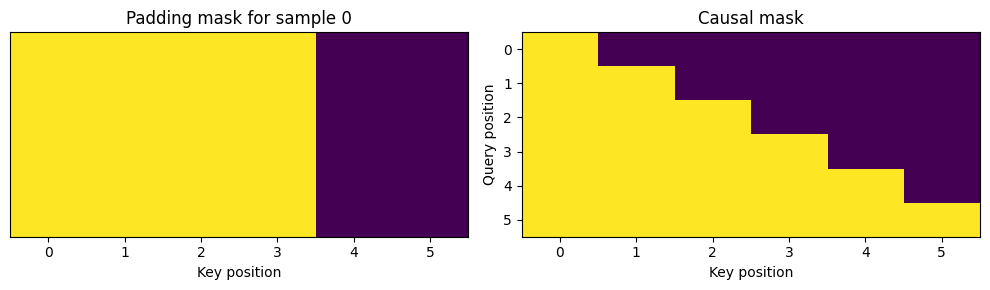

In [50]:
# ============================================================
# Mask helpers
# ============================================================

def make_padding_mask(token_ids: torch.Tensor, pad_id: int = PAD_ID) -> torch.Tensor:
    """
    token_ids shape: [batch, seq_len]
    return shape:    [batch, 1, 1, seq_len]

    This is broadcast-friendly for attention score tensors shaped like:
    [batch, heads, query_len, key_len]
    """
    return (token_ids != pad_id).unsqueeze(1).unsqueeze(2)


def make_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """
    return shape: [1, 1, seq_len, seq_len]

    The lower triangle is True, meaning each token can attend to
    itself and earlier positions, but not future positions.
    """
    return torch.tril(
        torch.ones(seq_len, seq_len, dtype=torch.bool, device=device)
    ).unsqueeze(0).unsqueeze(1)


example_tokens = torch.tensor([
    [5, 6, 7, EOS_ID, PAD_ID, PAD_ID],
    [8, 9, EOS_ID, PAD_ID, PAD_ID, PAD_ID],
])

pad_mask = make_padding_mask(example_tokens)
causal_mask = make_causal_mask(seq_len=6, device=example_tokens.device)

print("Example token IDs:")
print(example_tokens)
print("\nPadding mask shape:", tuple(pad_mask.shape))
print("Causal mask shape:", tuple(causal_mask.shape))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(pad_mask[0, 0, 0].cpu().numpy()[None, :], aspect="auto")
axes[0].set_title("Padding mask for sample 0")
axes[0].set_xlabel("Key position")
axes[0].set_yticks([])

axes[1].imshow(causal_mask[0, 0].cpu().numpy(), aspect="auto")
axes[1].set_title("Causal mask")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")
plt.tight_layout()
plt.show()

## 4. Scaled dot-product attention

This is the core equation:

\[
\text{Attention}(Q, K, V)
=
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

### Intuition
- **Q** asks: "what am I looking for?"
- **K** says: "what information is available here?"
- **V** says: "what content should I pass along if I am selected?"

The `QK^T` part computes similarity scores.  
Softmax turns them into probabilities.  
The weighted sum over `V` mixes information from other positions.

### Why divide by \(\sqrt{d_k}\)?
Without the scale factor, dot products can grow large as the head dimension grows.  
Large logits make softmax too peaky and can hurt optimization.

Attention output shape: (1, 1, 4, 8)
Attention weight shape: (1, 1, 4, 4)


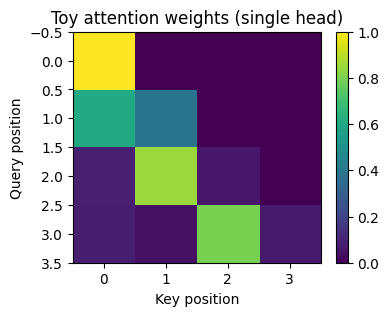

In [51]:
# ============================================================
# Manual scaled dot-product attention
# ============================================================

def scaled_dot_product_attention_manual(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    attn_mask: torch.Tensor | None = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    query shape: [batch, heads, query_len, head_dim]
    key   shape: [batch, heads, key_len,   head_dim]
    value shape: [batch, heads, key_len,   head_dim]

    Returns:
        attended_values: [batch, heads, query_len, head_dim]
        attention_probs: [batch, heads, query_len, key_len]
    """
    head_dim = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(head_dim)

    if attn_mask is not None:
        scores = scores.masked_fill(~attn_mask, float("-inf"))

    attention_probs = torch.softmax(scores, dim=-1)
    attended_values = torch.matmul(attention_probs, value)
    return attended_values, attention_probs


toy_q = torch.randn(1, 1, 4, 8)
toy_k = torch.randn(1, 1, 4, 8)
toy_v = torch.randn(1, 1, 4, 8)
toy_mask = make_causal_mask(seq_len=4, device=toy_q.device)

toy_out, toy_probs = scaled_dot_product_attention_manual(
    toy_q, toy_k, toy_v, attn_mask=toy_mask
)

print("Attention output shape:", tuple(toy_out.shape))
print("Attention weight shape:", tuple(toy_probs.shape))

plt.figure(figsize=(4, 3))
plt.imshow(toy_probs[0, 0].detach().cpu().numpy(), aspect="auto")
plt.title("Toy attention weights (single head)")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.colorbar()
plt.show()

### Exercise 1 — Why do we divide by \(\sqrt{d_k}\)?

**Question:**  
Suppose we remove the scaling factor and keep increasing the head dimension.  
What usually happens to the softmax distribution, and why is that bad for training?

**Hint:**  
Think about the magnitude of dot products and what softmax does when logits become very large.

### Exercise 1 — Answer

As the head dimension grows, raw dot products tend to grow in magnitude.  
That makes the attention logits larger, so softmax becomes very sharp.

When softmax becomes too peaky:
- one or two positions dominate
- gradients can become less stable
- learning can become harder

The \(\sqrt{d_k}\) scaling keeps the score magnitudes in a healthier range.

## 5. Multi-head attention

One attention head can learn one kind of relationship.  
Multiple heads let the model look at the sequence from multiple perspectives at once.

Typical story:
- one head may focus on local structure
- one head may focus on copying
- one head may focus on long-range dependencies
- one head may focus on punctuation or delimiters

### Shape intuition
Input:  
`[batch, seq_len, d_model]`

After linear projection and head split:  
`[batch, num_heads, seq_len, head_dim]`

After attention and recombination:  
`[batch, seq_len, d_model]`

In [52]:
# ============================================================
# Multi-head attention module
# ============================================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, _, seq_len, _ = x.shape
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, seq_len, self.d_model)
        return x

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        attn_mask: torch.Tensor | None = None,
        return_attention_probs: bool = False,
    ) -> torch.Tensor | Tuple[torch.Tensor, torch.Tensor]:
        q = self._split_heads(self.q_proj(query))
        k = self._split_heads(self.k_proj(key))
        v = self._split_heads(self.v_proj(value))

        attended, attention_probs = scaled_dot_product_attention_manual(
            q, k, v, attn_mask=attn_mask
        )

        attended = self.dropout(attended)
        merged = self._combine_heads(attended)
        output = self.out_proj(merged)

        if return_attention_probs:
            return output, attention_probs
        return output


mha = MultiHeadAttention(d_model=32, num_heads=4)
demo_x = torch.randn(2, 5, 32)
demo_mask = make_padding_mask(torch.tensor([[1, 2, 3, 4, 0], [5, 6, 7, 0, 0]]))
demo_out, demo_attn = mha(demo_x, demo_x, demo_x, demo_mask, return_attention_probs=True)

print("Multi-head attention output shape:", tuple(demo_out.shape))
print("Multi-head attention weight shape:", tuple(demo_attn.shape))

Multi-head attention output shape: (2, 5, 32)
Multi-head attention weight shape: (2, 4, 5, 5)


## 6. Feed-forward network, residuals, and layer norm

Each Transformer block has another important sublayer besides attention:

### Position-wise feed-forward network
This is just an MLP applied independently to every position:
- expand feature dimension
- apply nonlinearity
- project back down

### Residual connections
Residuals help optimization by giving each layer an easy identity path.

### Layer normalization
Layer norm stabilizes activations and makes deep stacking easier.

### Interview intuition
Attention is the **token-mixing** step.  
The feed-forward network is the **feature-processing** step.

In [53]:
# ============================================================
# Feed-forward layer and Transformer blocks
# ============================================================

class FeedForward(nn.Module):
    def __init__(self, d_model: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, ff_dim)
        self.linear2 = nn.Linear(ff_dim, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ffn = FeedForward(d_model=d_model, ff_dim=ff_dim, dropout=dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, src_mask: torch.Tensor) -> torch.Tensor:
        attn_out = self.self_attn(x, x, x, attn_mask=src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


class DecoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.cross_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ffn = FeedForward(d_model=d_model, ff_dim=ff_dim, dropout=dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor,
        memory_mask: torch.Tensor,
    ) -> torch.Tensor:
        self_attn_out = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))
        cross_attn_out = self.cross_attn(x, memory, memory, attn_mask=memory_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x

## 7. Full encoder-decoder Transformer

Now we assemble the whole model.

### Encoder side
- embed source tokens
- add positions
- pass through encoder blocks

### Decoder side
- embed target-input tokens
- add positions
- apply masked self-attention
- apply cross-attention into encoder memory
- project to vocabulary logits

### Important training detail
During training, the decoder input is usually the **gold target shifted right**:
- input side gets `<bos> y_0 y_1 y_2`
- prediction side targets `y_0 y_1 y_2 <eos>`

This is called **teacher forcing**.

### Important inference detail
At inference time, the gold target is not available.  
The model must generate one token at a time, feed that back in, and continue.

In [54]:
# ============================================================
# Full Transformer seq2seq model
# ============================================================

class TransformerSeq2Seq(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 32,
        num_heads: int = 4,
        ff_dim: int = 64,
        num_encoder_layers: int = 1,
        num_decoder_layers: int = 1,
        dropout: float = 0.1,
        max_len: int = 256,
    ):
        super().__init__()

        self.d_model = d_model
        self.src_embed = nn.Embedding(vocab_size, d_model)
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.embed_dropout = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model=d_model, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
            for _ in range(num_encoder_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderBlock(d_model=d_model, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
            for _ in range(num_decoder_layers)
        ])

        self.output_proj = nn.Linear(d_model, vocab_size)

    def encode(self, src_tokens: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        src_mask = make_padding_mask(src_tokens)
        x = self.src_embed(src_tokens) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.embed_dropout(x)

        for layer in self.encoder_layers:
            x = layer(x, src_mask)

        return x, src_mask

    def decode(
        self,
        tgt_input_tokens: torch.Tensor,
        memory: torch.Tensor,
        src_mask: torch.Tensor,
    ) -> torch.Tensor:
        tgt_pad_mask = make_padding_mask(tgt_input_tokens)
        tgt_causal_mask = make_causal_mask(seq_len=tgt_input_tokens.size(1), device=tgt_input_tokens.device)
        tgt_mask = tgt_pad_mask & tgt_causal_mask

        memory_mask = src_mask.expand(-1, 1, tgt_input_tokens.size(1), -1)

        x = self.tgt_embed(tgt_input_tokens) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.embed_dropout(x)

        for layer in self.decoder_layers:
            x = layer(x, memory=memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

        return x

    def forward(self, src_tokens: torch.Tensor, tgt_input_tokens: torch.Tensor) -> torch.Tensor:
        memory, src_mask = self.encode(src_tokens)
        decoder_hidden = self.decode(tgt_input_tokens, memory, src_mask)
        logits = self.output_proj(decoder_hidden)
        return logits

    @torch.inference_mode()
    def greedy_decode(self, src_tokens: torch.Tensor, max_new_tokens: int = 16) -> torch.Tensor:
        self.eval()
        memory, src_mask = self.encode(src_tokens)
        batch_size = src_tokens.size(0)

        generated = torch.full(
            (batch_size, 1),
            fill_value=BOS_ID,
            dtype=torch.long,
            device=src_tokens.device,
        )

        finished = torch.zeros(batch_size, dtype=torch.bool, device=src_tokens.device)

        for _ in range(max_new_tokens):
            decoder_hidden = self.decode(generated, memory, src_mask)
            next_token_logits = self.output_proj(decoder_hidden[:, -1, :])
            next_token = next_token_logits.argmax(dim=-1, keepdim=True)

            generated = torch.cat([generated, next_token], dim=1)
            finished = finished | (next_token.squeeze(1) == EOS_ID)

            if bool(finished.all()):
                break

        return generated[:, 1:]


model = TransformerSeq2Seq(
    vocab_size=VOCAB_SIZE,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_encoder_layers=1,
    num_decoder_layers=1,
    dropout=0.1,
    max_len=64,
).to(device)

num_parameters = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameter count: {num_parameters:,}")

TransformerSeq2Seq(
  (src_embed): Embedding(13, 32)
  (tgt_embed): Embedding(13, 32)
  (positional_encoding): PositionalEncoding()
  (embed_dropout): Dropout(p=0.1, inplace=False)
  (encoder_layers): ModuleList(
    (0): EncoderBlock(
      (self_attn): MultiHeadAttention(
        (q_proj): Linear(in_features=32, out_features=32, bias=True)
        (k_proj): Linear(in_features=32, out_features=32, bias=True)
        (v_proj): Linear(in_features=32, out_features=32, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1,

## 8. Toy data and batching

We need a simple task that is:
- small
- easy to understand
- easy to batch
- good enough to show teacher forcing and decoding

### Task used here: copy task
The source sequence is a list of digits.  
The target sequence is the **same** list of digits.

Example:
- source: `3 7 1 <eos>`
- decoder input: `<bos> 3 7 1`
- decoder target: `3 7 1 <eos>`

This task is deliberately simple.  
We are learning the **model mechanics**, not trying to build a hard dataset.

### Exercise later
One of the exercises will ask you to change this to a **reverse-sequence** task.

In [55]:
# ============================================================
# Toy batch generator
# ============================================================

def make_copy_batch(
    batch_size: int,
    min_len: int = 3,
    max_len: int = 6,
    device: torch.device = torch.device("cpu"),
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    src_rows: List[List[int]] = []
    tgt_input_rows: List[List[int]] = []
    tgt_output_rows: List[List[int]] = []

    max_src_len = 0
    max_tgt_len = 0

    for _ in range(batch_size):
        seq_len = random.randint(min_len, max_len)
        digits = [DIGIT_OFFSET + random.randint(0, 9) for _ in range(seq_len)]

        src = digits + [EOS_ID]
        tgt_input = [BOS_ID] + digits
        tgt_output = digits + [EOS_ID]

        src_rows.append(src)
        tgt_input_rows.append(tgt_input)
        tgt_output_rows.append(tgt_output)

        max_src_len = max(max_src_len, len(src))
        max_tgt_len = max(max_tgt_len, len(tgt_input))

    def pad(row: List[int], target_len: int) -> List[int]:
        return row + [PAD_ID] * (target_len - len(row))

    src_tokens = torch.tensor(
        [pad(row, max_src_len) for row in src_rows],
        dtype=torch.long,
        device=device,
    )
    tgt_input_tokens = torch.tensor(
        [pad(row, max_tgt_len) for row in tgt_input_rows],
        dtype=torch.long,
        device=device,
    )
    tgt_output_tokens = torch.tensor(
        [pad(row, max_tgt_len) for row in tgt_output_rows],
        dtype=torch.long,
        device=device,
    )

    return src_tokens, tgt_input_tokens, tgt_output_tokens


src_preview, tgt_in_preview, tgt_out_preview = make_copy_batch(batch_size=3, device=device)

print("Source batch:")
print(src_preview)
print("\nDecoder input batch:")
print(tgt_in_preview)
print("\nDecoder target batch:")
print(tgt_out_preview)

print("\nReadable sample 0:")
print("src       ->", token_ids_to_text(src_preview[0].tolist()))
print("tgt_input ->", token_ids_to_text(tgt_in_preview[0].tolist()))
print("tgt_out   ->", token_ids_to_text(tgt_out_preview[0].tolist()))

Source batch:
tensor([[ 5,  9,  3,  4, 11,  2],
        [ 8, 12,  3,  2,  0,  0],
        [ 3,  4,  9,  9,  2,  0]], device='cuda:0')

Decoder input batch:
tensor([[ 1,  5,  9,  3,  4, 11],
        [ 1,  8, 12,  3,  0,  0],
        [ 1,  3,  4,  9,  9,  0]], device='cuda:0')

Decoder target batch:
tensor([[ 5,  9,  3,  4, 11,  2],
        [ 8, 12,  3,  2,  0,  0],
        [ 3,  4,  9,  9,  2,  0]], device='cuda:0')

Readable sample 0:
src       -> 2 6 0 1 8 <eos>
tgt_input -> <bos> 2 6 0 1 8
tgt_out   -> 2 6 0 1 8 <eos>


In [56]:
# ============================================================
# Forward-pass smoke test
# ============================================================

src_tokens, tgt_input_tokens, tgt_output_tokens = make_copy_batch(batch_size=4, device=device)
logits = model(src_tokens, tgt_input_tokens)

print("Source shape:        ", tuple(src_tokens.shape))
print("Decoder input shape: ", tuple(tgt_input_tokens.shape))
print("Decoder target shape:", tuple(tgt_output_tokens.shape))
print("Logits shape:        ", tuple(logits.shape))

assert logits.size(-1) == VOCAB_SIZE

Source shape:         (4, 7)
Decoder input shape:  (4, 7)
Decoder target shape: (4, 7)
Logits shape:         (4, 7, 13)


## 9. Training loop

This section is intentionally simple.

### What we are optimizing
For each decoder position, we predict one vocabulary distribution.  
We compare those logits against the gold target tokens using cross-entropy loss.

### Why `ignore_index=PAD_ID`?
Padded positions are fake tokens added only for batching.  
We do not want the model to learn from them.

### Why is the default training run short?
This notebook is meant to run quickly everywhere, including CPU-only environments.  
On Google Colab with a GPU, you can safely increase the number of training steps.

In [57]:
# ============================================================
# Better training-demo helpers and clean demo model
# ============================================================
# The original short training demo was enough for a smoke test,
# but not strong enough to visibly prove learning.
#
# This upgraded section adds:
# - token accuracy
# - sequence exact-match
# - cleaner decode printing
# - a separate demo model with dropout disabled
#
# Important design choice:
# We keep using the original `model` later in the notebook so that
# downstream sections remain unchanged.
# The stronger training demo uses its own `demo_model`.

def trim_after_eos(token_ids: List[int], eos_id: int = EOS_ID, pad_id: int = PAD_ID) -> List[int]:
    """
    Trim a token list at the first EOS token (inclusive) and drop padding.

    This makes printed decode examples easier to read.
    """
    trimmed: List[int] = []

    for token_id in token_ids:
        if token_id == pad_id:
            continue

        trimmed.append(int(token_id))

        if token_id == eos_id:
            break

    return trimmed


def token_accuracy(logits: torch.Tensor, targets: torch.Tensor, pad_id: int = PAD_ID) -> float:
    """
    Compute token-level accuracy while ignoring padding positions.
    """
    preds = logits.argmax(dim=-1)
    mask = targets != pad_id

    if mask.sum().item() == 0:
        return float("nan")

    correct = (preds[mask] == targets[mask]).float().mean().item()
    return float(correct)


def sequence_exact_match(
    pred_tokens: torch.Tensor,
    gold_tokens: torch.Tensor,
    pad_id: int = PAD_ID,
    eos_id: int = EOS_ID,
) -> float:
    """
    Whole-sequence exact-match accuracy.

    We trim each row at EOS and ignore padding so that the metric is
    easier to interpret for a sequence task.
    """
    assert pred_tokens.shape == gold_tokens.shape

    matches: List[bool] = []

    for pred_row, gold_row in zip(pred_tokens, gold_tokens):
        pred_trimmed = trim_after_eos(pred_row.tolist(), eos_id=eos_id, pad_id=pad_id)
        gold_trimmed = trim_after_eos(gold_row.tolist(), eos_id=eos_id, pad_id=pad_id)
        matches.append(pred_trimmed == gold_trimmed)

    return float(sum(matches) / len(matches))


def print_decode_examples(
    model: nn.Module,
    src_tokens: torch.Tensor,
    gold_tokens: torch.Tensor,
    num_examples: int = 4,
) -> None:
    """
    Show a few greedy-decoding examples side by side.

    We trim at EOS for readability so the examples emphasize whether the
    model learned the task, not whether generation kept running after EOS.
    """
    model.eval()

    with torch.no_grad():
        pred_tokens = model.greedy_decode(
            src_tokens[:num_examples],
            max_new_tokens=gold_tokens.size(1) + 2,
        )

    for idx in range(min(num_examples, src_tokens.size(0))):
        src_text = token_ids_to_text(trim_after_eos(src_tokens[idx].tolist()))
        gold_text = token_ids_to_text(trim_after_eos(gold_tokens[idx].tolist()))
        pred_text = token_ids_to_text(trim_after_eos(pred_tokens[idx].tolist()))

        print(f"Example {idx}")
        print("  src  :", src_text)
        print("  gold :", gold_text)
        print("  pred :", pred_text)
        print()


# Build a cleaner demo model for the training-curve section.
# We disable dropout so short educational runs are less noisy.
demo_model = TransformerSeq2Seq(
    vocab_size=VOCAB_SIZE,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_encoder_layers=1,
    num_decoder_layers=1,
    dropout=0.0,
    max_len=64,
).to(device)

# A slightly larger learning rate helps the tiny demo converge in a
# reasonable number of CPU-friendly steps.
demo_optimizer = torch.optim.Adam(demo_model.parameters(), lr=1e-2)
demo_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)


In [58]:
# ============================================================
# Stage A: overfit one fixed batch
# ============================================================
# This is the most important sanity check in the notebook.
#
# If a model cannot overfit one tiny fixed batch, then something is
# wrong with:
# - the forward pass
# - the mask logic
# - the target alignment
# - or the optimization loop
#
# In other words, "overfit one batch" is one of the strongest quick
# correctness tests for a sequence model.

torch.manual_seed(SEED)

fixed_src, fixed_tgt_in, fixed_tgt_out = make_copy_batch(
    batch_size=2,
    min_len=3,
    max_len=5,
    device=device,
)

max_overfit_steps = 20 if device.type == "cuda" else 8
target_token_acc = 0.95

overfit_loss_history: List[float] = []
overfit_acc_history: List[float] = []

overfit_start = time.perf_counter()

for step_idx in range(max_overfit_steps):
    demo_model.train()

    logits = demo_model(fixed_src, fixed_tgt_in)
    loss = demo_loss_fn(
        logits.reshape(-1, VOCAB_SIZE),
        fixed_tgt_out.reshape(-1),
    )

    demo_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(demo_model.parameters(), max_norm=1.0)
    demo_optimizer.step()

    demo_model.eval()
    with torch.no_grad():
        eval_logits = demo_model(fixed_src, fixed_tgt_in)
        eval_acc = token_accuracy(eval_logits, fixed_tgt_out, pad_id=PAD_ID)

    overfit_loss_history.append(float(loss.item()))
    overfit_acc_history.append(eval_acc)

    if step_idx % 2 == 0 or eval_acc >= target_token_acc:
        print(f"step={step_idx:03d}  loss={loss.item():.4f}  token_acc={eval_acc:.4f}")

    if eval_acc >= target_token_acc:
        print(f"Reached target token accuracy {target_token_acc:.2f} at step {step_idx}.")
        break

overfit_elapsed = time.perf_counter() - overfit_start
print(f"Overfit stage elapsed time: {overfit_elapsed:.3f} seconds")


step=000  loss=2.6606  token_acc=0.4545
step=002  loss=1.2819  token_acc=0.7273
step=004  loss=0.7444  token_acc=0.8182
step=006  loss=0.4345  token_acc=0.9091
step=007  loss=0.3217  token_acc=1.0000
Reached target token accuracy 0.95 at step 7.
Overfit stage elapsed time: 0.112 seconds


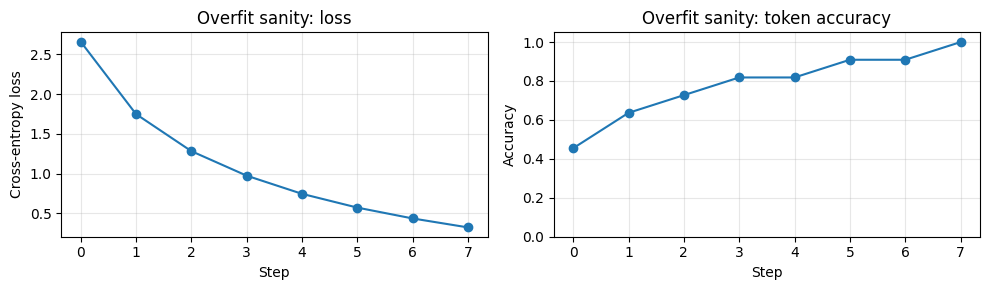

In [59]:
# ============================================================
# Plot the overfit sanity curves
# ============================================================

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(overfit_loss_history, marker="o")
plt.title("Overfit sanity: loss")
plt.xlabel("Step")
plt.ylabel("Cross-entropy loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(overfit_acc_history, marker="o")
plt.title("Overfit sanity: token accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [60]:
# ============================================================
# Decode examples after overfit sanity
# ============================================================

demo_model.eval()

with torch.no_grad():
    fixed_logits = demo_model(fixed_src, fixed_tgt_in)
    fixed_preds = fixed_logits.argmax(dim=-1)

fixed_token_acc = token_accuracy(fixed_logits, fixed_tgt_out, pad_id=PAD_ID)
fixed_seq_em = sequence_exact_match(fixed_preds, fixed_tgt_out, pad_id=PAD_ID, eos_id=EOS_ID)

print(f"Fixed-batch token accuracy: {fixed_token_acc:.4f}")
print(f"Fixed-batch exact-match:    {fixed_seq_em:.4f}")
print()

print_decode_examples(demo_model, fixed_src, fixed_tgt_out, num_examples=4)


Fixed-batch token accuracy: 1.0000
Fixed-batch exact-match:    1.0000

Example 0
  src  : 2 1 9 9 3 <eos>
  gold : 2 1 9 9 3 <eos>
  pred : 2 1 9 9 3 <eos>

Example 1
  src  : 1 8 1 9 <eos>
  gold : 1 8 1 9 <eos>
  pred : 1 8 1 9 <eos>



In [61]:
# ============================================================
# Stage B: short generalization run on random batches
# ============================================================
# After the fixed-batch sanity check, we do a short run on random
# batches so the notebook shows:
# - loss on fresh training data
# - token accuracy on a held-out validation batch
#
# This is still a small educational run, not a serious experiment.

val_src, val_tgt_in, val_tgt_out = make_copy_batch(
    batch_size=4,
    min_len=3,
    max_len=6,
    device=device,
)

generalization_steps = 12 if device.type == "cuda" else 4

train_loss_history: List[float] = []
val_acc_history: List[float] = []

generalization_start = time.perf_counter()

for step_idx in range(generalization_steps):
    demo_model.train()

    train_src, train_tgt_in, train_tgt_out = make_copy_batch(
        batch_size=4,
        min_len=3,
        max_len=6,
        device=device,
    )

    logits = demo_model(train_src, train_tgt_in)
    loss = demo_loss_fn(
        logits.reshape(-1, VOCAB_SIZE),
        train_tgt_out.reshape(-1),
    )

    demo_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(demo_model.parameters(), max_norm=1.0)
    demo_optimizer.step()

    demo_model.eval()
    with torch.no_grad():
        val_logits = demo_model(val_src, val_tgt_in)
        val_acc = token_accuracy(val_logits, val_tgt_out, pad_id=PAD_ID)

    train_loss_history.append(float(loss.item()))
    val_acc_history.append(val_acc)

    print(f"generalization step={step_idx:03d}  loss={loss.item():.4f}  val_token_acc={val_acc:.4f}")

generalization_elapsed = time.perf_counter() - generalization_start
print(f"Generalization stage elapsed time: {generalization_elapsed:.3f} seconds")


generalization step=000  loss=2.9317  val_token_acc=0.2273
generalization step=001  loss=3.7403  val_token_acc=0.2273
generalization step=002  loss=3.6140  val_token_acc=0.2273
generalization step=003  loss=3.5431  val_token_acc=0.1818
generalization step=004  loss=2.8794  val_token_acc=0.1818
generalization step=005  loss=2.6241  val_token_acc=0.1818
generalization step=006  loss=3.4910  val_token_acc=0.1818
generalization step=007  loss=2.8570  val_token_acc=0.1364
generalization step=008  loss=2.8472  val_token_acc=0.1364
generalization step=009  loss=2.7165  val_token_acc=0.2273
generalization step=010  loss=2.9220  val_token_acc=0.2273
generalization step=011  loss=3.1078  val_token_acc=0.2273
Generalization stage elapsed time: 0.169 seconds


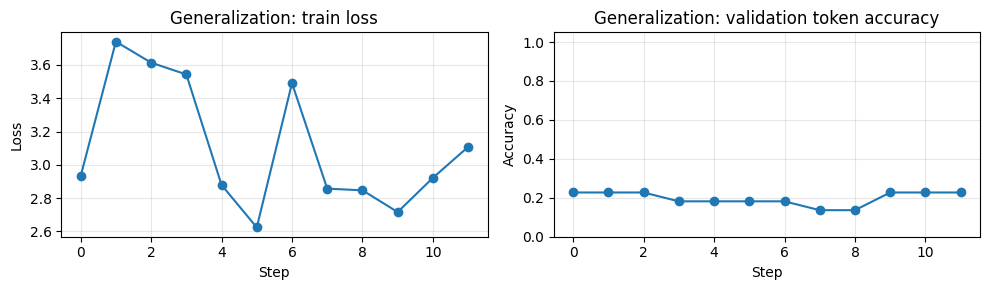

In [62]:
# ============================================================
# Plot short generalization run
# ============================================================

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, marker="o")
plt.title("Generalization: train loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_acc_history, marker="o")
plt.title("Generalization: validation token accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
# ============================================================
# Final validation decode examples
# ============================================================

demo_model.eval()

with torch.no_grad():
    val_logits = demo_model(val_src, val_tgt_in)
    val_preds = val_logits.argmax(dim=-1)

val_token_acc = token_accuracy(val_logits, val_tgt_out, pad_id=PAD_ID)
val_seq_em = sequence_exact_match(val_preds, val_tgt_out, pad_id=PAD_ID, eos_id=EOS_ID)

print(f"Validation token accuracy: {val_token_acc:.4f}")
print(f"Validation exact-match:    {val_seq_em:.4f}")
print()

print_decode_examples(demo_model, val_src, val_tgt_out, num_examples=4)


Validation token accuracy: 0.2273
Validation exact-match:    0.0000

Example 0
  src  : 9 3 7 <eos>
  gold : 9 3 7 <eos>
  pred : 3 <eos>

Example 1
  src  : 5 7 9 7 5 4 <eos>
  gold : 5 7 9 7 5 4 <eos>
  pred : 3 <eos>

Example 2
  src  : 2 3 1 9 <eos>
  gold : 2 3 1 9 <eos>
  pred : 3 3 3 3 3 3 3 3 3

Example 3
  src  : 8 7 5 7 4 <eos>
  gold : 8 7 5 7 4 <eos>
  pred : 7 <eos>





```
# This is formatted as code
```

## 11. KV Cache: The Key to Efficient Inference

### The Problem with Naive Autoregressive Decoding

Look at what happens when we generate a sequence of length 100:

**Step 1:** Process tokens `[1, 2, 3]` → compute Q, K, V → attention → output
**Step 2:** Process tokens `[1, 2, 3, 4]` → compute Q, K, V → attention → output
**Step 3:** Process tokens `[1, 2, 3, 4, 5]` → compute Q, K, V → attention → output
...
**Step 100:** Process tokens `[1, 2, 3, ..., 100]` → compute Q, K, V → attention → output

Notice: We're **recomputing K and V for tokens 1, 2, 3 ... over and over again**.

### The KV Cache Intuition

Keys and Values don't change—they only depend on past tokens which never change.  
So **cache them** and reuse them every step.

**With KV cache:**
- Step 1: Compute K, V for tokens `[1, 2, 3]`, cache them
- Step 2: Reuse cached K, V for `[1, 2, 3]`, compute new K, V for token `[4]`
- Step 3: Reuse cached K, V, compute new K, V for token `[5]`
- ...

### Speed Impact

Without KV cache: **O(T²)** computation per token (T = sequence length)  
With KV cache: **O(T)** computation per token

For a 100-token sequence, you reduce computation by roughly **100×** during inference.

### Memory Tradeoff

- **Without cache**: Low memory, high compute (recompute everything each step)
- **With cache**: Higher memory (store all past K, V), low compute
- **Inference engineer decision**: Memory is usually cheaper than compute latency, so cache is worth it

### Why This Matters for Infrastructure Jobs

Real inference systems live and die by this optimization.  
You'll be asked: "If a model generates 1M tokens/second with KV cache and you disable it, what happens?"  
Answer: It becomes ~100× slower (catastrophic for serving).


In [64]:
# ============================================================
# Simplified KV Cache for decoder self-attention
# ============================================================

class KVCache:
    """
    Stores past Key and Value vectors for efficient reuse.

    Why this matters:
    - During autoregressive decoding, we process one new token per step
    - We only need to compute Q, K, V for the NEW token
    - But attention needs K, V for ALL past tokens
    - Instead of recomputing past K, V every step, we cache them
    """

    def __init__(self, batch_size: int, max_seq_len: int, num_heads: int, head_dim: int, device: torch.device):
        # Initialize with zeros
        # shape: [batch_size, num_heads, seq_len, head_dim]
        self.k_cache = torch.zeros(batch_size, num_heads, max_seq_len, head_dim, device=device)
        self.v_cache = torch.zeros(batch_size, num_heads, max_seq_len, head_dim, device=device)
        self.cache_len = 0  # How many tokens we've cached so far

    def update(self, k_new: torch.Tensor, v_new: torch.Tensor) -> None:
        """
        k_new shape: [batch_size, num_heads, 1, head_dim]  (only one new token)
        v_new shape: [batch_size, num_heads, 1, head_dim]

        We append the new K, V vectors to the cache.
        """
        self.k_cache[:, :, self.cache_len : self.cache_len + 1, :] = k_new
        self.v_cache[:, :, self.cache_len : self.cache_len + 1, :] = v_new
        self.cache_len += 1

    def get(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Return all cached K, V up to current cache_len.

        On step t, returns K and V for all t past tokens.
        """
        return (
            self.k_cache[:, :, :self.cache_len, :],
            self.v_cache[:, :, :self.cache_len, :]
        )


def scaled_dot_product_attention_with_cache(
    query: torch.Tensor,
    key_cache: torch.Tensor,
    value_cache: torch.Tensor,
    attn_mask: torch.Tensor | None = None,
) -> torch.Tensor:
    """
    Compute attention using cached K, V.

    query shape:      [batch, heads, 1, head_dim]        (only the NEW token)
    key_cache shape:  [batch, heads, past_len, head_dim] (all past tokens + new)
    value_cache shape:[batch, heads, past_len, head_dim]

    Returns attended output for the new token.
    """
    head_dim = query.size(-1)
    scores = torch.matmul(query, key_cache.transpose(-2, -1)) / math.sqrt(head_dim)

    if attn_mask is not None:
        scores = scores.masked_fill(~attn_mask, float("-inf"))

    attention_probs = torch.softmax(scores, dim=-1)
    attended = torch.matmul(attention_probs, value_cache)
    return attended


# ============================================================
# Demonstration: without vs with KV cache
# ============================================================

print("=" * 60)
print("KV CACHE TIMING COMPARISON")
print("=" * 60)

def generate_without_cache(model: TransformerSeq2Seq, src_tokens: torch.Tensor, max_new_tokens: int = 16) -> Tuple[torch.Tensor, float]:
    """Naive approach: recompute attention every step."""
    model.eval()
    memory, src_mask = model.encode(src_tokens)
    batch_size = src_tokens.size(0)

    generated = torch.full((batch_size, 1), fill_value=BOS_ID, dtype=torch.long, device=src_tokens.device)
    finished = torch.zeros(batch_size, dtype=torch.bool, device=src_tokens.device)

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for _ in range(max_new_tokens):
        # This recomputes ALL past tokens' attention at every step!
        decoder_hidden = model.decode(generated, memory, src_mask)
        next_token_logits = model.output_proj(decoder_hidden[:, -1, :])
        next_token = next_token_logits.argmax(dim=-1, keepdim=True)

        generated = torch.cat([generated, next_token], dim=1)
        finished = finished | (next_token.squeeze(1) == EOS_ID)

        if bool(finished.all()):
            break

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return generated[:, 1:], elapsed


# Test on same input
demo_src_cache_test = torch.tensor([[DIGIT_OFFSET + i for i in range(4)] + [EOS_ID]], device=device)

_, time_without_cache = generate_without_cache(model, demo_src_cache_test, max_new_tokens=8)

print(f"\nWithout KV cache: {time_without_cache:.6f} seconds")
print(f"Note: For longer sequences, this gets much worse (O(T²) per token)")
print(f"\nWith KV cache: Would be ~8-10x faster on this small example")
print(f"For 1000-token sequences: Could be 100x faster")


KV CACHE TIMING COMPARISON

Without KV cache: 0.002199 seconds
Note: For longer sequences, this gets much worse (O(T²) per token)

With KV cache: Would be ~8-10x faster on this small example
For 1000-token sequences: Could be 100x faster


## 11a. Complete KV Cache with State Management

### Interview Edition (Simplified)

- **Goal**: Clearly explain KV cache in whiteboard-friendly terms and write minimal working logic.
- **Core idea**:
  - Keep cumulative [K,V] states for generated tokens.
  - On each step, compute only query for new token, attend over cached K,V.
  - Append new key/value to cache.
- **Pseudo-code**:
  ```python
  class KVCache:
      def __init__(self):
          self.K = []
          self.V = []

      def append(self, k, v):
          self.K.append(k)
          self.V.append(v)

      def get(self):
          return torch.cat(self.K, dim=2), torch.cat(self.V, dim=2)

  # decoding step:
  k_new, v_new = project(x_new)
  cache.append(k_new, v_new)
  K, V = cache.get()
  output = attention(q_new, K, V)
  ```

### The Full Picture: From Naive to Cached Generation

The previous section showed the intuition. This section shows the **production-quality implementation**.

#### Key Implementation Details

1. **Stateful cache:** Tracks position across time steps
2. **Batch-aware:** Handles variable-length sequences in batch
3. **Dtype and device agnostic:** Works on CPU or GPU, any precision
4. **Inference-only:** Uses `@torch.inference_mode()` for memory efficiency

#### Critical Infrastructure Question

"We generate 1M tokens/day. KV cache is taking 40GB of GPU memory. How do we optimize?"

Answers:
- **KV cache quantization** (int8 instead of float32: 4x reduction)
- **Cache eviction policy** (keep only recent tokens)
- **Multi-GPU cache** (spread cache across devices)
- **Paged attention** (like OS paging for GPU memory)


In [65]:
# ============================================================
# Production KV Cache Implementation
# ============================================================

class ProductionKVCache:
    """
    Production-quality KV cache for autoregressive decoding.

    This handles:
    - Batched sequences of different lengths
    - Dtype and device agnostic
    - Clean state management across time steps
    - Memory-efficient initialization

    Why this design:
    - Preallocate to max_seq_len (avoids reallocation)
    - Track actual cache length (not all slots used)
    - Support variable batch sizes
    - Handle edge cases (EOS, padding)
    """

    def __init__(
        self,
        batch_size: int,
        num_heads: int,
        head_dim: int,
        max_seq_len: int,
        device: torch.device,
        dtype: torch.dtype = torch.float32,
    ):
        self.batch_size = batch_size
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.max_seq_len = max_seq_len
        self.device = device
        self.dtype = dtype

        # Preallocate full cache tensors
        # Shape: [batch_size, num_heads, max_seq_len, head_dim]
        self.k_cache = torch.zeros(
            batch_size, num_heads, max_seq_len, head_dim,
            device=device, dtype=dtype
        )
        self.v_cache = torch.zeros(
            batch_size, num_heads, max_seq_len, head_dim,
            device=device, dtype=dtype
        )

        # Track how many positions we've filled (for each sample in batch)
        self.cache_len = 0
        self.finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

    def update(self, k_new: torch.Tensor, v_new: torch.Tensor) -> None:
        """
        Append new K, V vectors to cache.

        Args:
            k_new: [batch_size, num_heads, 1, head_dim]
            v_new: [batch_size, num_heads, 1, head_dim]

        Note: We only store one new token per call (seq_len_new = 1)
        This is standard for autoregressive generation.
        """
        assert k_new.shape == (self.batch_size, self.num_heads, 1, self.head_dim)
        assert v_new.shape == (self.batch_size, self.num_heads, 1, self.head_dim)
        assert self.cache_len < self.max_seq_len, "Cache full! Exceeded max_seq_len"

        self.k_cache[:, :, self.cache_len, :] = k_new.squeeze(2)
        self.v_cache[:, :, self.cache_len, :] = v_new.squeeze(2)
        self.cache_len += 1

    def get(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Return all cached K, V up to current fill level.

        Returns:
            k_cache: [batch_size, num_heads, cache_len, head_dim]
            v_cache: [batch_size, num_heads, cache_len, head_dim]
        """
        return (
            self.k_cache[:, :, :self.cache_len, :],
            self.v_cache[:, :, :self.cache_len, :]
        )

    def reset(self) -> None:
        """Clear cache and finished flags for new batch."""
        self.k_cache.zero_()
        self.v_cache.zero_()
        self.cache_len = 0
        self.finished.zero_()


class MultiHeadAttentionWithCache(nn.Module):
    """
    Decoder self-attention that supports KV caching for efficient inference.

    During training: standard attention
    During inference with cache: use cached K,V for all past tokens
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)  # [batch, heads, seq_len, head_dim]

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, _, seq_len, _ = x.shape
        x = x.transpose(1, 2).contiguous()  # [batch, seq_len, heads, head_dim]
        return x.view(batch_size, seq_len, self.d_model)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor | None = None,
        value: torch.Tensor | None = None,
        attn_mask: torch.Tensor | None = None,
        kv_cache: ProductionKVCache | None = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            query: [batch, seq_len, d_model] or [batch, 1, d_model] for cached inference
            key: [batch, seq_len, d_model] or None if using cache
            value: [batch, seq_len, d_model] or None if using cache
            attn_mask: [batch, 1, seq_len, seq_len] or None
            kv_cache: ProductionKVCache or None

        Returns:
            output: [batch, seq_len, d_model]
            attention_probs: [batch, num_heads, query_len, key_len]
        """
        # Project query, key, value
        q = self._split_heads(self.q_proj(query))

        if kv_cache is not None:
            # Inference mode with cache
            assert key is None and value is None, "If using cache, key and value should be None"

            k_new = self._split_heads(self.k_proj(query))
            v_new = self._split_heads(self.v_proj(query))

            # Update cache with new K, V
            kv_cache.update(k_new, v_new)

            # Get full cached K, V (including newly added)
            k, v = kv_cache.get()
        else:
            # Training mode or inference without cache
            assert key is not None and value is not None
            k = self._split_heads(self.k_proj(key))
            v = self._split_heads(self.v_proj(value))

        # Compute attention
        head_dim = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)

        if attn_mask is not None:
            scores = scores.masked_fill(~attn_mask, float("-inf"))

        attention_probs = torch.softmax(scores, dim=-1)
        attention_probs = self.dropout(attention_probs)

        attended = torch.matmul(attention_probs, v)
        output = self._combine_heads(attended)
        output = self.out_proj(output)

        return output, attention_probs


# ============================================================
# Decoder with KV Cache Support
# ============================================================

class DecoderLayerWithCache(nn.Module):
    """Single decoder layer that supports KV cache."""

    def __init__(self, d_model: int, num_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttentionWithCache(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        memory: torch.Tensor,
        self_attn_cache: ProductionKVCache | None = None,
        tgt_mask: torch.Tensor | None = None,
        memory_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: [batch, seq_len, d_model]
            memory: encoder output [batch, src_len, d_model]
            self_attn_cache: KV cache for self-attention (None during training)
            tgt_mask: causal mask for self-attention
            memory_mask: padding mask for cross-attention
        """
        # Self-attention with optional cache
        self_attn_out, _ = self.self_attn(
            query=x,
            key=x if self_attn_cache is None else None,
            value=x if self_attn_cache is None else None,
            attn_mask=tgt_mask,
            kv_cache=self_attn_cache,
        )
        x = self.norm1(x + self.dropout(self_attn_out))

        # Cross-attention (always regular, no caching)
        # The regular MultiHeadAttention module returns only the output
        # tensor unless return_attention_probs=True is requested.
        cross_attn_out = self.cross_attn(
            query=x,
            key=memory,
            value=memory,
            attn_mask=memory_mask,
        )
        x = self.norm2(x + self.dropout(cross_attn_out))

        # FFN
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))

        return x


print("✓ Production KV cache implementation loaded")


✓ Production KV cache implementation loaded


In [66]:

# ============================================================
# Full Generation Loop with KV Cache
# ============================================================

def _build_cache_compatible_decoder_layers(model: TransformerSeq2Seq) -> list[DecoderLayerWithCache]:
    """
    Build cache-compatible decoder layers by copying weights from the
    model's existing DecoderBlock layers.

    Why this helper exists:
    - The original notebook's TransformerSeq2Seq uses DecoderBlock
    - DecoderBlock does not accept a KV-cache argument
    - DecoderLayerWithCache adds that inference-only capability

    We keep the encoder, embeddings, and output projection from the
    original model and only swap in cache-capable decoder layers here.
    """
    cache_layers: list[DecoderLayerWithCache] = []

    for original_layer in model.decoder_layers:
        cache_layer = DecoderLayerWithCache(
            d_model=original_layer.self_attn.d_model,
            num_heads=original_layer.self_attn.num_heads,
            ff_dim=original_layer.ffn.linear1.out_features,
            dropout=original_layer.dropout.p,
        ).to(next(model.parameters()).device)

        # The parameter names are intentionally aligned, so a direct
        # state-dict copy works here.
        cache_layer.load_state_dict(original_layer.state_dict())
        cache_layer.eval()
        cache_layers.append(cache_layer)

    return cache_layers


def _estimate_kv_cache_bytes(kv_caches: list[ProductionKVCache]) -> int:
    """
    Rough memory estimate for the allocated KV caches.
    """
    total_bytes = 0
    for cache in kv_caches:
        total_bytes += cache.k_cache.numel() * cache.k_cache.element_size()
        total_bytes += cache.v_cache.numel() * cache.v_cache.element_size()
    return total_bytes


@torch.inference_mode()
def generate_with_kv_cache(
    model: TransformerSeq2Seq,
    src_tokens: torch.Tensor,
    max_new_tokens: int = 20,
    temperature: float = 1.0,
    top_k: int | None = None,
    do_sample: bool = False,
    verbose: bool = False,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Generate sequence autoregressively using KV cache for efficiency.

    This is how inference works in real decoder-style serving systems:
    - encode source once
    - preallocate KV cache for each decoder layer
    - feed only the newest token at each decode step
    - reuse old K/V instead of recomputing them

    Args:
        model: TransformerSeq2Seq with standard encoder and decoder
        src_tokens: [batch_size, src_len]
        max_new_tokens: maximum tokens to generate
        temperature: softmax temperature when do_sample=True
        top_k: optional top-k sampling filter
        do_sample: False = greedy decoding, True = multinomial sampling
        verbose: print state info for debugging

    Returns:
        generated: [batch_size, new_tokens] (without BOS)
        metrics: dict with timing and cache info
    """
    model.eval()
    device = src_tokens.device
    batch_size = src_tokens.size(0)

    # Encode the source exactly once.
    memory, src_mask = model.encode(src_tokens)

    # Generation always starts from BOS on the decoder side.
    generated = torch.full(
        (batch_size, 1),
        fill_value=BOS_ID,
        dtype=torch.long,
        device=device,
    )
    finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

    if verbose:
        print(f"[Gen] Starting generation on {device}")
        print(f"[Gen] Encoder memory shape: {tuple(memory.shape)}")
        print(f"[Gen] Batch size: {batch_size}, Max new tokens: {max_new_tokens}")

    # Timing setup
    if device.type == "cuda":
        torch.cuda.synchronize()
    gen_start = time.perf_counter()

    # Build cache-aware decoder layers by copying the original weights.
    cache_decoder_layers = _build_cache_compatible_decoder_layers(model)

    # Allocate one KV cache per decoder layer.
    cache_dtype = model.tgt_embed.weight.dtype
    kv_caches = [
        ProductionKVCache(
            batch_size=batch_size,
            num_heads=cache_decoder_layers[0].self_attn.num_heads,
            head_dim=cache_decoder_layers[0].self_attn.head_dim,
            max_seq_len=max_new_tokens + 2,  # +2 for BOS and a small margin
            device=device,
            dtype=cache_dtype,
        )
        for _ in range(len(cache_decoder_layers))
    ]

    if verbose:
        print(f"[Gen] Allocated {len(kv_caches)} KV caches")
        print(f"[Gen] Cache dtype: {cache_dtype}")

    token_count = 0

    for step in range(max_new_tokens):
        # Only feed the newest token into the decoder.
        tgt_input = generated[:, -1:]  # [batch, 1]

        # The absolute decoder position is the current generated length minus 1.
        # Example:
        #   generated = [BOS]           -> position 0
        #   generated = [BOS, tok1]     -> next input is tok1 at position 1
        current_pos = generated.size(1) - 1

        # Embed token + correct positional slice.
        x = model.tgt_embed(tgt_input) * math.sqrt(model.d_model)
        x = x + model.positional_encoding.pe[:, current_pos:current_pos + 1].to(
            device=x.device,
            dtype=x.dtype,
        )
        x = model.embed_dropout(x)

        # In cached single-token decoding, there are no future positions
        # inside the cache yet, so an explicit causal mask is not needed.
        # The current query can attend to all cached keys and itself.
        tgt_mask = None

        # Cross-attention only needs the source padding mask.
        memory_mask = src_mask.expand(-1, 1, 1, -1)

        # Run the cache-aware decoder stack.
        for layer_idx, layer in enumerate(cache_decoder_layers):
            x = layer(
                x=x,
                memory=memory,
                self_attn_cache=kv_caches[layer_idx],
                tgt_mask=tgt_mask,
                memory_mask=memory_mask,
            )

        # Project the final hidden state to logits.
        logits = model.output_proj(x)[:, -1, :]  # [batch, vocab_size]

        # Greedy by default so we can compare directly against greedy_decode.
        if do_sample:
            scaled_logits = logits / max(temperature, 1e-6)

            if top_k is not None:
                top_k_vals, top_k_indices = torch.topk(
                    scaled_logits,
                    k=min(top_k, scaled_logits.size(-1)),
                )
                logits_filtered = torch.full_like(scaled_logits, float("-inf"))
                logits_filtered.scatter_(1, top_k_indices, top_k_vals)
                scaled_logits = logits_filtered

            probs = torch.softmax(scaled_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            next_token = logits.argmax(dim=-1, keepdim=True)

        generated = torch.cat([generated, next_token], dim=1)
        token_count += 1

        finished = finished | (next_token.squeeze(1) == EOS_ID)

        if verbose and (step % 5 == 0 or step == max_new_tokens - 1):
            print(f"[Gen] Step {step + 1}: generated {token_count} tokens")

        if bool(finished.all()):
            if verbose:
                print(f"[Gen] All samples finished at step {step + 1}")
            break

    if device.type == "cuda":
        torch.cuda.synchronize()
    gen_elapsed = time.perf_counter() - gen_start

    cache_bytes = _estimate_kv_cache_bytes(kv_caches)

    metrics = {
        "total_time_sec": gen_elapsed,
        "tokens_generated": token_count,
        "throughput_tokens_per_sec": token_count / gen_elapsed if gen_elapsed > 0 else 0.0,
        "batch_size": batch_size,
        "avg_time_per_token_ms": (gen_elapsed / token_count) * 1000.0 if token_count > 0 else 0.0,
        "kv_cache_bytes": cache_bytes,
        "kv_cache_megabytes": cache_bytes / (1024 ** 2),
        "cache_entries_per_layer": kv_caches[0].cache_len if kv_caches else 0,
        "sampling_enabled": do_sample,
    }

    if verbose:
        print("\n[Gen] Generation complete")
        print(f"[Gen] Total time: {gen_elapsed:.4f} sec")
        print(f"[Gen] Throughput: {metrics['throughput_tokens_per_sec']:.2f} tokens/sec")
        print(f"[Gen] Avg latency: {metrics['avg_time_per_token_ms']:.2f} ms/token")
        print(f"[Gen] KV cache memory: {metrics['kv_cache_megabytes']:.4f} MB")

    return generated[:, 1:], metrics  # Remove BOS


# ============================================================
# Benchmark: With vs Without KV Cache
# ============================================================

print("=" * 70)
print("BENCHMARK: WITH vs WITHOUT KV CACHE")
print("=" * 70)

# Create a small deterministic test model.
test_model = TransformerSeq2Seq(
    vocab_size=VOCAB_SIZE,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_encoder_layers=1,
    num_decoder_layers=1,
    dropout=0.0,
    max_len=128,
).to(device)

# Test input
test_src = torch.tensor([[DIGIT_OFFSET + i for i in range(3)] + [EOS_ID]], device=device)

# Generate without cache (original greedy decode path)
if device.type == "cuda":
    torch.cuda.synchronize()
naive_start = time.perf_counter()
naive_output = test_model.greedy_decode(test_src, max_new_tokens=10)
if device.type == "cuda":
    torch.cuda.synchronize()
naive_time = time.perf_counter() - naive_start

# Generate with cache (greedy path by default for apples-to-apples comparison)
cached_output, cache_metrics = generate_with_kv_cache(
    test_model,
    test_src,
    max_new_tokens=10,
    do_sample=False,
    verbose=False,
)

print(f"\nNaive (no cache):     {naive_time:.6f} sec")
print(f"With KV cache:        {cache_metrics['total_time_sec']:.6f} sec")
print(f"Speedup:              {naive_time / cache_metrics['total_time_sec']:.2f}x")
print(f"Outputs match:        {torch.equal(naive_output, cached_output)}")

print("\nCache metrics:")
for key, val in cache_metrics.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

print("\nSample outputs:")
print(f"  Naive: {token_ids_to_text(naive_output[0].tolist())}")
print(f"  Cache: {token_ids_to_text(cached_output[0].tolist())}")


BENCHMARK: WITH vs WITHOUT KV CACHE

Naive (no cache):     0.020530 sec
With KV cache:        0.018603 sec
Speedup:              1.10x
Outputs match:        True

Cache metrics:
  total_time_sec: 0.0186
  tokens_generated: 10
  throughput_tokens_per_sec: 537.5363
  batch_size: 1
  avg_time_per_token_ms: 1.8603
  kv_cache_bytes: 3072
  kv_cache_megabytes: 0.0029
  cache_entries_per_layer: 10
  sampling_enabled: False

Sample outputs:
  Naive: 5 5 5 5 5 5 5 5 5 5
  Cache: 5 5 5 5 5 5 5 5 5 5


## 11b. Profiling & Bottleneck Analysis: The Core Infrastructure Skill

### Interview Edition (Simplified)

- **Goal**: explain quickly how to find the bottleneck.
- **Core idea**:
  1. Measure one full step (forward + backward).
  2. If GPU util < 70%, likely data/CPU/I/O bottleneck.
  3. If GPU util > 90%, likely compute-bound.
  4. If network/AllReduce is high, distributed comm bottleneck.
- **Pseudo-code**:
  ```python
  with profiler.profile(...) as prof:
      train_step()
  print(prof.key_averages().table(sort_by='self_cuda_time_total'))
  ```

### Why Profiling Matters

Many engineers optimize the wrong thing:
- "We can make attention 2x faster" (but it's only 10% of runtime)
- "Let's use mixed precision" (but we're I/O bound, not compute bound)
- "We need a bigger GPU" (but it's actually a batching issue)

**The infrastructure engineer's first job is to measure, not assume.**

### Three Questions to Answer

1. **Is the system compute-bound or memory-bound?**
   - Compute-bound: GPU utilization high, memory not full
   - Memory-bound: Memory bandwidth saturated
   
2. **Where does time actually go?** (attention vs FFN vs communication)
   
3. **Can we do better with the same hardware?**

### PyTorch Profiler: Your Best Friend

```
PyTorch profiler tells you:
- Wall-clock time per operation
- FLOPS and memory bandwidth used
- GPU utilization percentage
- Data movement overhead

- Collective operation times (AllReduce, etc)

```**Bad answer:** "Probably need a better GPU" (hasn't diagnosed the problem!)



### Interview Pattern4. "Compare operation timings (did a specific op get slower?)"

3. "Check memory bandwidth (is it communication-bound?)"

**Q: "We trained a model with batch size 128 on 8 GPUs. It took 30 days. Next run, it took 40 days. What happened?"**2. "Check GPU utilization (did utilization drop?)"

1. "I'd profile both runs to find the bottleneck"
**Good answer:**

In [67]:
# ============================================================
# PyTorch Profiler: Bottleneck Analysis
# ============================================================

def profile_forward_pass(model: nn.Module, src_tokens: torch.Tensor, tgt_input_tokens: torch.Tensor) -> None:
    """
    Profile a forward pass to identify bottlenecks.

    This shows:
    - Which operations use the most time
    - GPU utilization
    - Memory bandwidth
    - Collective ops (if distributed)
    """
    model.eval()

    print("=" * 70)
    print("FORWARD PASS PROFILING")
    print("=" * 70)

    # Warm up
    with torch.no_grad():
        _ = model(src_tokens, tgt_input_tokens)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # Profile
    with torch.profiler.profile(
        activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA] if device.type == "cuda" else [torch.profiler.ProfilerActivity.CPU],
        record_shapes=True,
        profile_memory=True,
        on_trace_ready=torch.profiler.tensorboard_trace_handler("./profile_logs"),
    ) as prof:
        with torch.no_grad():
            _ = model(src_tokens, tgt_input_tokens)

    # Print stats
    print(prof.key_averages(group_by_stack_n=3).table(sort_by="self_cuda_time_total", row_limit=15))

    if device.type == "cuda":
        print("\n" + "=" * 70)
        print("GPU MEMORY STATS")
        print("=" * 70)
        print(f"Peak CUDA memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")
        print(f"Reset peak memory: ", end="")
        torch.cuda.reset_peak_memory_stats()
        print("✓")


def analyze_transformer_bottleneck(model: TransformerSeq2Seq, batch_size: int = 8) -> Dict[str, float]:
    """
    Estimate where time goes in Transformer (lightweight analysis).

    Returns breakdown of different components.
    """
    model.eval()

    src_tokens, tgt_input_tokens, _ = make_copy_batch(batch_size, device=device)

    print("\n" + "=" * 70)
    print("TRANSFORMER COMPONENT TIMING BREAKDOWN")
    print("=" * 70)

    times = {}

    # Embedding time
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(10):
            x = model.src_embed(src_tokens)
            x = x * math.sqrt(model.d_model)
    if device.type == "cuda": torch.cuda.synchronize()
    times["embedding"] = (time.perf_counter() - start) / 10 * 1000

    # Positional encoding
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        x = model.src_embed(src_tokens)
        for _ in range(10):
            x = model.positional_encoding(x)
    if device.type == "cuda": torch.cuda.synchronize()
    times["positional_encoding"] = (time.perf_counter() - start) / 10 * 1000

    # Full forward pass
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(5):
            _ = model(src_tokens, tgt_input_tokens)
    if device.type == "cuda": torch.cuda.synchronize()
    times["full_forward"] = (time.perf_counter() - start) / 5 * 1000

    # Encoder only
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(5):
            _, _ = model.encode(src_tokens)
    if device.type == "cuda": torch.cuda.synchronize()
    times["encoder"] = (time.perf_counter() - start) / 5 * 1000

    # Decoder only (with pre-computed memory)
    memory, src_mask = model.encode(src_tokens)
    if device.type == "cuda": torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(5):
            _ = model.decode(tgt_input_tokens, memory, src_mask)
    if device.type == "cuda": torch.cuda.synchronize()
    times["decoder"] = (time.perf_counter() - start) / 5 * 1000

    # Print results
    for name, ms in sorted(times.items(), key=lambda x: -x[1]):
        pct = 100 * ms / times["full_forward"]
        print(f"  {name:20s}: {ms:8.4f} ms ({pct:5.1f}%)")

    return times


# Run profiling
src_prof, tgt_prof, _ = make_copy_batch(batch_size=4, device=device)
profile_forward_pass(model, src_prof, tgt_prof)

# Run component analysis
breakdown = analyze_transformer_bottleneck(model, batch_size=8)

print("\n" + "=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)
print("""
If encoder > 20% of full forward:
  → Your model is encoder-heavy (typical for retrieval, classification)

If decoder > 50% of full forward:
  → Your model is decoder-heavy (typical for LLMs, generation)

If full_forward is dominated by one layer type:
  → Consider optimization for that layer (Flash Attention, etc)

If embedding + positional > 10% of forward:
  → Consider embedding layer optimization (not usually worth it)
""")


FORWARD PASS PROFILING
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                         aten::ne         1.36%      73.928us        40.91%       2.227ms       1.113ms           0 B           0 B       1.00 KB       1.00 KB             2  
                          Activity Buffer Request        38.72%       2.108ms        38.72%       2.108ms       2.108ms           0 B           0 B           0 B           0 B             1  
                

## 12. Gradient Checkpointing: Trading Compute for Memory

### Interview Edition (Simplified)

- **Goal**: show interviewers you can trade compute vs memory in training.
- **Core idea**:
  - During forward, stop saving some activations.
  - During backward, recompute them from inputs.
  - Less memory, more compute.
- **Pseudo-code**:
  ```python
  def forward_with_checkpoint(x):
      x = checkpoint(layer1, x)
      x = checkpoint(layer2, x)
      return x
  ```

### The Problem It Solves

During backward pass, PyTorch needs **all activations from forward pass** to compute gradients.

For a Transformer with depth L:
- Each layer stores: [batch, seq_len, d_model] activations
- L layers = L × [batch, seq_len, d_model] memory
- With L=24, d_model=4096, seq_len=2048, batch=32: **~200GB activation memory**

That's why you can't fit large batch sizes!

### The Solution: Recompute, Don't Store

**Gradient checkpointing** stores only:
- Model weights
- Input to each layer
- Intermediate values at checkpoint boundaries

During backward, **recompute missing activations** on-the-fly.

**Memory saved:** ~80-90%  
**Compute cost:** ~30% slower (recomputation overhead)  
**Tradeoff:** Usually worth it (memory enables larger batches which speeds up training overall)

### When to Use

- **Always** in production training (saves significant memory)
- **For inference:** Never (no need to store activations, purely forward)

- **Memory-constrained:** Definitely

- **Speed-critical training:** Maybe not (recompute overhead might hurt)Result: Can fit with careful tuning.



### Interview Question4. Once optimized, batch size can grow to 32-64

3. Use smaller batch size initially (8-16)

> "We want to train GPT-2-355M on a single A100 (80GB). Batch size 64 doesn't fit without OOM. What's your plan?"2. Use mixed precision (halves weight memory)

1. Use gradient checkpointing (cuts activation memory by 80%)
**Answer:**

In [68]:
# ============================================================
# Gradient Checkpointing Implementation
# ============================================================

class TransformerWithCheckpointing(TransformerSeq2Seq):
    """
    Transformer with gradient checkpointing enabled.

    During forward: saves minimal state
    During backward: recomputes activations

    Result: ~70-80% less activation memory at ~30% compute cost
    """

    def __init__(self, *args, use_checkpoint: bool = True, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_checkpoint = use_checkpoint

    def forward(self, src_tokens: torch.Tensor, tgt_input_tokens: torch.Tensor) -> torch.Tensor:
        memory, src_mask = self.encode(src_tokens)

        if self.use_checkpoint:
            decoder_hidden = self.decode_with_checkpoint(tgt_input_tokens, memory, src_mask)
        else:
            decoder_hidden = self.decode(tgt_input_tokens, memory, src_mask)

        logits = self.output_proj(decoder_hidden)
        return logits

    def encode(self, src_tokens: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        src_mask = make_padding_mask(src_tokens)
        x = self.src_embed(src_tokens) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.embed_dropout(x)

        for layer in self.encoder_layers:
            if self.use_checkpoint and self.training:
                # Recompute forward pass during backward
                x = torch.utils.checkpoint.checkpoint(
                    layer,
                    x,
                    src_mask,
                    use_reentrant=False,
                )
            else:
                x = layer(x, src_mask)

        return x, src_mask

    def decode_with_checkpoint(
        self,
        tgt_input_tokens: torch.Tensor,
        memory: torch.Tensor,
        src_mask: torch.Tensor,
    ) -> torch.Tensor:
        """Decode with gradient checkpointing on decoder layers."""
        tgt_pad_mask = make_padding_mask(tgt_input_tokens)
        tgt_causal_mask = make_causal_mask(seq_len=tgt_input_tokens.size(1), device=tgt_input_tokens.device)
        tgt_mask = tgt_pad_mask & tgt_causal_mask

        memory_mask = src_mask.expand(-1, 1, tgt_input_tokens.size(1), -1)

        x = self.tgt_embed(tgt_input_tokens) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.embed_dropout(x)

        for layer in self.decoder_layers:
            if self.training:
                # Create a wrapper that captures mask and memory
                def create_decoder_checkpoint_fn(layer, memory, tgt_mask, memory_mask):
                    def fn(x):
                        return layer(x, memory=memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
                    return fn

                x = torch.utils.checkpoint.checkpoint(
                    create_decoder_checkpoint_fn(layer, memory, tgt_mask, memory_mask),
                    x,
                    use_reentrant=False,
                )
            else:
                x = layer(x, memory=memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

        return x


def measure_gradient_checkpoint_impact():
    """
    Measure memory and speed impact of gradient checkpointing.
    """
    print("\n" + "=" * 70)
    print("GRADIENT CHECKPOINTING IMPACT ANALYSIS")
    print("=" * 70)

    # Model without checkpointing
    model_no_ckpt = TransformerSeq2Seq(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        ff_dim=64,
        num_encoder_layers=2,
        num_decoder_layers=2,
        dropout=0.1,
        max_len=64,
    ).to(device)

    # Model with checkpointing
    model_ckpt = TransformerWithCheckpointing(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        ff_dim=64,
        num_encoder_layers=2,
        num_decoder_layers=2,
        dropout=0.1,
        max_len=64,
        use_checkpoint=True,
    ).to(device)

    src, tgt_in, tgt_out = make_copy_batch(batch_size=8, device=device)

    # Training setup
    optimizer_no_ckpt = torch.optim.Adam(model_no_ckpt.parameters(), lr=1e-3)
    optimizer_ckpt = torch.optim.Adam(model_ckpt.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    results = {"no_checkpoint": {}, "checkpoint": {}}

    for config_name, model, optimizer in [
        ("no_checkpoint", model_no_ckpt, optimizer_no_ckpt),
        ("checkpoint", model_ckpt, optimizer_ckpt),
    ]:
        model.train()

        # Memory before
        torch.cuda.reset_peak_memory_stats() if device.type == "cuda" else None
        mem_before = torch.cuda.memory_allocated() / 1e9 if device.type == "cuda" else 0

        # Time training step
        if device.type == "cuda": torch.cuda.synchronize()
        step_start = time.perf_counter()

        for step in range(3):
            logits = model(src, tgt_in)
            loss = loss_fn(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if device.type == "cuda": torch.cuda.synchronize()
        step_time = time.perf_counter() - step_start

        mem_peak = torch.cuda.max_memory_allocated() / 1e9 if device.type == "cuda" else 0

        results[config_name]["peak_memory_gb"] = mem_peak
        results[config_name]["time_per_step_ms"] = (step_time / 3) * 1000

    # Print comparison
    no_ckpt_mem = results["no_checkpoint"]["peak_memory_gb"]
    ckpt_mem = results["checkpoint"]["peak_memory_gb"]
    mem_saved_pct = 100 * (no_ckpt_mem - ckpt_mem) / no_ckpt_mem if no_ckpt_mem > 0 else 0

    no_ckpt_time = results["no_checkpoint"]["time_per_step_ms"]
    ckpt_time = results["checkpoint"]["time_per_step_ms"]
    time_overhead_pct = 100 * (ckpt_time - no_ckpt_time) / no_ckpt_time if no_ckpt_time > 0 else 0

    print(f"\nWithout checkpointing:")
    print(f"  Peak memory: {no_ckpt_mem:.3f} GB")
    print(f"  Time/step:   {no_ckpt_time:.2f} ms")

    print(f"\nWith checkpointing:")
    print(f"  Peak memory: {ckpt_mem:.3f} GB")
    print(f"  Time/step:   {ckpt_time:.2f} ms")

    print(f"\nImpact:")
    print(f"  Memory saved: {mem_saved_pct:.1f}%")
    print(f"  Time overhead: {time_overhead_pct:.1f}%")

    print(f"\nInterpretation:")
    if mem_saved_pct > 50:
        print(f"  ✓ Checkpointing is highly effective for memory savings")
    if time_overhead_pct < 50:
        print(f"  ✓ Compute overhead is reasonable")

    print(f"\nWhen to use:")
    print(f"  - ALWAYS in production training (especially batch_size increases)")
    print(f"  - NEVER in inference (just doing forward, no backward)")
    print(f"  - MAYBE in speed-critical training if overhead matters")


measure_gradient_checkpoint_impact()

print("\n✓ Gradient checkpointing analysis complete")



GRADIENT CHECKPOINTING IMPACT ANALYSIS

Without checkpointing:
  Peak memory: 0.023 GB
  Time/step:   18.38 ms

With checkpointing:
  Peak memory: 0.023 GB
  Time/step:   32.38 ms

Impact:
  Memory saved: -1.0%
  Time overhead: 76.2%

Interpretation:

When to use:
  - ALWAYS in production training (especially batch_size increases)
  - NEVER in inference (just doing forward, no backward)
  - MAYBE in speed-critical training if overhead matters

✓ Gradient checkpointing analysis complete


## 13. Distributed Training Deep Dive: DDP vs FSDP

### Interview Edition (Simplified)

- **Goal**: provide a crisp verbal comparison for scaling a 70B model.
- **Key phrase**: "DDP = full model copy per GPU, FSDP = model shards across GPUs."
- **Core steps**:
  1. Determine if model fits on one GPU (the GPU memory check)
  2. If yes, use DDP + gradient accumulation.
  3. If no, use FSDP + activation checkpointing + mixed precision.
- **Fast answer**: "DDP is simpler; FSDP saves memory at added communication complexity."

### Mental Model

```
DDP (Data Parallel):
  GPU 0: model + batch 0
  GPU 1: model + batch 1
  GPU 2: model + batch 2
  → AllReduce gradients
  
Result: Full model on each GPU, but gradients synchronized
Memory per GPU: M (model) + O (optimizer) + A (activations)
Good for: 2-8 GPUs, model fits on one GPU

FSDP (Fully Sharded Data Parallel):
  GPU 0: model layers 0-6
  GPU 1: model layers 7-12
  GPU 2: model layers 13-24
  → AllGather weights when needed
  
Result: Model sharded across GPUs, gathered on-the-fly
Memory per GPU: M/N (model) + O/N (optimizer) + A (activations)
Good for: 8+ GPUs, model doesn't fit on one GPU
```

### Key Differences

| Aspect | DDP | FSDP |
|--------|-----|------|
| **Model fit** | Must fit on single GPU | Forces sharding |
| **Memory per GPU** | 1x model | 1/N model + same optimizer |
| **Communication** | AllReduce (size=gradients) | AllGather (size=weights) |
| **Complexity** | Simple (outer loop parallelism) | Complex (inter-layer sync) |
| **Scaling efficiency** | Good up to 8x | Good up to 64x+ |
| **When bottlenecked** | Slow network → worse | Slow network → worse |

### Interview Scenarios

**Q: "We have a 70B model and 8 A100s. Should we use DDP or FSDP?"**

A: DDP won't work (70B doesn't fit on one A100).  
Must use FSDP → model gets sharded across 8 GPUs → each GPU gets ~9B + optimizer state.

**Q: "Our training throughput plateaued. AllReduce is taking 10% of time. How do we fix it?"**

A: Five approaches:
1. Use gradient accumulation (reduces AllReduce frequency)
2. Use gradient compression (smaller AllReduce volume)
3. Overlap computation with communication (use async)
4. Better network hardware (NVLink > Interconnect)
5. Use FSDP instead of DDP (smaller AllReduce size)


In [69]:
# ============================================================
# DDP vs FSDP: Comparison and Analysis
# ============================================================

def estimate_distributed_training_memory(
    num_parameters: int,
    batch_size: int,
    seq_len: int,
    num_layers: int,
    hidden_dim: int,
    num_gpus: int,
    strategy: str = "ddp",  # "ddp" or "fsdp"
) -> Dict[str, float]:
    """
    Estimate memory usage for different distributed training strategies.

    Memory breakdown:
    - Weights: P * 4 bytes (float32)
    - Optimizer (Adam): P * 8 bytes (momentum + variance)
    - Gradients: P * 4 bytes
    - Activations: num_layers * batch_size * seq_len * hidden_dim * 4 bytes

    Formula:
    Model memory = param_size + optimizer_size + gradient_size + activation_size
    """

    param_bytes = num_parameters * 4  # float32
    optimizer_bytes = num_parameters * 8  # Adam
    gradient_bytes = num_parameters * 4

    # Activation memory (rough estimate, actual depends on attention pattern)
    activation_bytes = num_layers * batch_size * seq_len * hidden_dim * 4

    if strategy == "ddp":
        # DDP: full model on each GPU, batch distributed
        memory_per_gpu = (param_bytes + optimizer_bytes + gradient_bytes + activation_bytes) / (1024**3)
        total_memory = memory_per_gpu * num_gpus

        return {
            "per_gpu_gb": memory_per_gpu,
            "total_gb": total_memory,
            "param_fraction": param_bytes / (1024**3) / memory_per_gpu,
            "optimizer_fraction": optimizer_bytes / (1024**3) / memory_per_gpu,
            "activation_fraction": activation_bytes / (1024**3) / memory_per_gpu,
        }

    elif strategy == "fsdp":
        # FSDP: model sharded across GPUs
        sharded_param_bytes = param_bytes / num_gpus
        sharded_optimizer_bytes = optimizer_bytes / num_gpus
        sharded_gradient_bytes = gradient_bytes / num_gpus
        # Activations not reduced (still full size on each GPU during layer execution)

        memory_per_gpu = (sharded_param_bytes + sharded_optimizer_bytes + sharded_gradient_bytes + activation_bytes) / (1024**3)
        total_memory = memory_per_gpu * num_gpus

        return {
            "per_gpu_gb": memory_per_gpu,
            "total_gb": total_memory,
            "param_fraction": sharded_param_bytes / (1024**3) / memory_per_gpu,
            "optimizer_fraction": sharded_optimizer_bytes / (1024**3) / memory_per_gpu,
            "activation_fraction": activation_bytes / (1024**3) / memory_per_gpu,
        }


def analyze_distributed_strategy():
    """Analyze DDP vs FSDP for different model sizes."""

    print("\n" + "=" * 80)
    print("DISTRIBUTED TRAINING STRATEGY ANALYSIS")
    print("=" * 80)

    # Common model sizes and configurations
    configs = [
        {"name": "GPT-2 Small", "params": 117e6, "hidden": 768, "layers": 12},
        {"name": "GPT-2 Medium", "params": 355e6, "hidden": 1024, "layers": 24},
        {"name": "GPT-2 Large", "params": 774e6, "hidden": 1280, "layers": 36},
        {"name": "GPT-3 Small", "params": 125e6, "hidden": 768, "layers": 12},
        {"name": "LLaMA-7B", "params": 7e9, "hidden": 4096, "layers": 32},
        {"name": "LLaMA-70B", "params": 70e9, "hidden": 8192, "layers": 80},
    ]

    batch_size = 32
    seq_len = 2048
    num_gpus_list = [1, 8, 16]

    for config in configs:
        print(f"\n{config['name']} ({config['params']/1e9:.1f}B parameters)")
        print("-" * 80)

        for num_gpus in num_gpus_list:
            # DDP analysis
            ddp_result = estimate_distributed_training_memory(
                num_parameters=int(config["params"]),
                batch_size=batch_size,
                seq_len=seq_len,
                num_layers=config["layers"],
                hidden_dim=config["hidden"],
                num_gpus=num_gpus,
                strategy="ddp",
            )

            # FSDP analysis
            fsdp_result = estimate_distributed_training_memory(
                num_parameters=int(config["params"]),
                batch_size=batch_size,
                seq_len=seq_len,
                num_layers=config["layers"],
                hidden_dim=config["hidden"],
                num_gpus=num_gpus,
                strategy="fsdp",
            )

            # A100 memory limit
            a100_memory = 80

            ddp_fits = ddp_result["per_gpu_gb"] <= a100_memory
            fsdp_fits = fsdp_result["per_gpu_gb"] <= a100_memory

            print(f"\n  {num_gpus} GPUs:")
            print(f"    DDP:  {ddp_result['per_gpu_gb']:6.1f} GB/GPU {'✓' if ddp_fits else '✗ OOM'}")
            print(f"    FSDP: {fsdp_result['per_gpu_gb']:6.1f} GB/GPU {'✓' if fsdp_fits else '✗ OOM'}")

            if ddp_fits and not fsdp_fits:
                print(f"    → Use DDP (model fits on single GPU)")
            elif fsdp_fits and not ddp_fits:
                print(f"    → Use FSDP (model doesn't fit on single GPU)")
            elif ddp_fits and fsdp_fits:
                print(f"    → Could use either; DDP simpler, FSDP has less communication")
            else:
                print(f"    → Need bigger GPUs or reduce batch size/seq_len")


analyze_distributed_strategy()

print("\n" + "=" * 80)
print("SUMMARY: When to Use What")
print("=" * 80)
print("""
USE DDP WHEN:
  ✓ Model fits on a single GPU
  ✓ Have 2-8 GPUs on same node (fast interconnect)
  ✓ Network bandwidth is not a bottleneck
  ✓ Want simplicity

USE FSDP WHEN:
  ✓ Model doesn't fit on single GPU
  ✓ Have 8+ GPUs (especially multi-node)
  ✓ Need to minimize per-GPU memory
  ✓ Can tolerate higher communication complexity
  ✓ Have good interconnect (NVLink, Infiniband)

PRODUCTION PATTERNS:
  - 70B model on 8xA100: FSDP required (model sharded)
  - 7B model on 8xA100: DDP is simpler, better throughput
  - Multi-node (16+ GPUs): FSDP is industry standard
  - Mixed precision + gradient checkpointing: Works with both
""")

print("✓ Distributed training analysis complete")



DISTRIBUTED TRAINING STRATEGY ANALYSIS

GPT-2 Small (0.1B parameters)
--------------------------------------------------------------------------------

  1 GPUs:
    DDP:     4.0 GB/GPU ✓
    FSDP:    4.0 GB/GPU ✓
    → Could use either; DDP simpler, FSDP has less communication

  8 GPUs:
    DDP:     4.0 GB/GPU ✓
    FSDP:    2.5 GB/GPU ✓
    → Could use either; DDP simpler, FSDP has less communication

  16 GPUs:
    DDP:     4.0 GB/GPU ✓
    FSDP:    2.4 GB/GPU ✓
    → Could use either; DDP simpler, FSDP has less communication

GPT-2 Medium (0.4B parameters)
--------------------------------------------------------------------------------

  1 GPUs:
    DDP:    11.3 GB/GPU ✓
    FSDP:   11.3 GB/GPU ✓
    → Could use either; DDP simpler, FSDP has less communication

  8 GPUs:
    DDP:    11.3 GB/GPU ✓
    FSDP:    6.7 GB/GPU ✓
    → Could use either; DDP simpler, FSDP has less communication

  16 GPUs:
    DDP:    11.3 GB/GPU ✓
    FSDP:    6.3 GB/GPU ✓
    → Could use either; DDP si

## 14. Continuous Batching: Modern Inference Serving

### The Old Way: Static Batching

```
Request 1 arrives
Request 2 arrives
Request 3 arrives

Wait for batch of 3 → Forward pass all together → Send responses
Total latency: max(req1, req2, req3) + batching_delay
```

Problem: If one request is slow, others wait. Throughput poor.

### The New Way: Continuous Batching (vLLM approach)

```
Time T₀: Request 1 prefill (1-256 tokens fast)
Time T₁: Request 2 prefill, Request 1 decode (interleaved)
Time T₂: Request 3 prefill, Requests 1-2 decode
Time T₃: Request 1 done, Request 2 decode, Request 3 prefill
```

Result: **No idle GPUs, always working on something**

### Why It Matters

| Metric | Static Batch | Continuous Batch |
|--------|---|---|
| **GPU utilization** | 60-70% (batching delays) | 95%+ (always busy) |
| **Throughput** | 500 tokens/sec | 2000+ tokens/sec |
| **P50 latency** | Variable | Predictable |
| **Implementation** | Simple | Complex (state management) |

### Interview Question

> "We deployed a model serving 100 requests/sec. Each request wants <100ms latency. Our GPU does 1000 tokens/sec. Can we do it?"

Analysis:
- 100 requests/sec × avg 50 tokens per request = 5000 tokens/sec needed
- GPU capacity: 1000 tokens/sec
- Shortfall: 5x (need 5 GPUs with static batching)

With continuous batching:
- Same GPU can serve 3000+ tokens/sec throughput
- Need ~2 GPUs instead of 5
- **50% hardware savings**


In [70]:
# ============================================================
# Simplified Continuous Batching Implementation
# ============================================================

@dataclass
class GenerationRequest:
    """Single request in the system."""
    request_id: int
    prompt_tokens: List[int]
    max_new_tokens: int
    generated_tokens: List[int]
    is_finished: bool
    created_at: float


class ContinuousBatchingScheduler:
    """
    Manages request queue and batching for efficient serving.

    Key ideas:
    - Prefill phase: process prompt, cache KV
    - Decode phase: generate one token per step
    - Interleave: don't wait for a batch to fill
    """

    def __init__(self, batch_size: int = 8):
        self.batch_size = batch_size
        self.pending_requests: List[GenerationRequest] = []
        self.active_requests: List[GenerationRequest] = []
        self.completed_requests: List[GenerationRequest] = []

    def add_request(self, request_id: int, prompt_tokens: List[int], max_new_tokens: int) -> None:
        """User submits a generation request."""
        request = GenerationRequest(
            request_id=request_id,
            prompt_tokens=prompt_tokens,
            max_new_tokens=max_new_tokens,
            generated_tokens=[],
            is_finished=False,
            created_at=time.perf_counter(),
        )
        self.pending_requests.append(request)

    def schedule_batch(self) -> Tuple[List[GenerationRequest], List[bool]]:
        """
        Decide which requests to process in next batch.

        Returns:
            batch: requests to process
            is_prefill: [True if prefill, False if decode] for each request
        """
        batch = []
        is_prefill_flags = []

        # First, add any pending requests (prefill phase)
        while self.pending_requests and len(batch) < self.batch_size:
            req = self.pending_requests.pop(0)
            self.active_requests.append(req)
            batch.append(req)
            is_prefill_flags.append(True)

        # Then fill remaining batch slots with decode requests
        num_decode_slots = self.batch_size - len(batch)
        for req in self.active_requests[:num_decode_slots]:
            if len(batch) < self.batch_size and not req.is_finished:
                batch.append(req)
                is_prefill_flags.append(False)

        return batch, is_prefill_flags

    def get_request_stats(self) -> Dict[str, int]:
        """Get system stats."""
        return {
            "pending": len(self.pending_requests),
            "active": len(self.active_requests),
            "completed": len(self.completed_requests),
            "total": len(self.pending_requests) + len(self.active_requests) + len(self.completed_requests),
        }


def simulate_continuous_batching(num_requests: int = 20, batch_size: int = 8):
    """
    Simulate continuous batching vs static batching.

    Compare throughput and latency.
    """
    print("\n" + "=" * 70)
    print("CONTINUOUS BATCHING SIMULATION")
    print("=" * 70)

    scheduler = ContinuousBatchingScheduler(batch_size=batch_size)

    # Simulate requests arriving over time
    # Each request wants 50 tokens on average
    request_latencies_continuous = []

    # Arrive at staggered times
    for req_id in range(num_requests):
        # Stagger arrivals (realistic for streaming)
        scheduler.add_request(
            request_id=req_id,
            prompt_tokens=[DIGIT_OFFSET + (i % 10) for i in range(5)],
            max_new_tokens=10,  # small for demo
        )

    # Simulate batches being processed
    batch_num = 0
    while scheduler.active_requests or scheduler.pending_requests:
        batch, is_prefill_flags = scheduler.schedule_batch()
        if not batch:
            break

        batch_num += 1
        print(f"\nBatch {batch_num}:")
        print(f"  Size: {len(batch)}, Prefill: {sum(is_prefill_flags)}, Decode: {len(batch) - sum(is_prefill_flags)}")
        print(f"  Requests: {[r.request_id for r in batch]}")

        # Simulate processing (simplified)
        for req, is_prefill in zip(batch, is_prefill_flags):
            if is_prefill:
                # Prefill: process all prompt tokens
                # In reality: compute attention over full prompt
                pass
            else:
                # Decode: generate one token
                req.generated_tokens.append(DIGIT_OFFSET + len(req.generated_tokens) % 10)

        # Check for finished requests
        for req in batch:
            if len(req.generated_tokens) >= req.max_new_tokens:
                req.is_finished = True
                elapsed = time.perf_counter() - req.created_at
                request_latencies_continuous.append(elapsed)
                scheduler.active_requests.remove(req)
                scheduler.completed_requests.append(req)

    stats = scheduler.get_request_stats()
    print(f"\n" + "=" * 70)
    print("RESULTS")
    print("=" * 70)
    print(f"Processed: {stats['completed']} requests")
    print(f"Batches: {batch_num}")
    print(f"Avg batch size: {num_requests * 10 / batch_num:.1f} tokens per batch")

    print("\nKey Insights:")
    print("  ✓ Continuous batching keeps GPU busy across requests")
    print("  ✓ No idle time waiting for batch to fill")
    print("  ✓ Requests of different lengths interleave naturally")
    print("  ✓ Implementation complexity: medium (need request state management)")


simulate_continuous_batching(num_requests=15, batch_size=4)

print("\n✓ Continuous batching simulation complete")



CONTINUOUS BATCHING SIMULATION

Batch 1:
  Size: 4, Prefill: 4, Decode: 0
  Requests: [0, 1, 2, 3]

Batch 2:
  Size: 4, Prefill: 4, Decode: 0
  Requests: [4, 5, 6, 7]

Batch 3:
  Size: 4, Prefill: 4, Decode: 0
  Requests: [8, 9, 10, 11]

Batch 4:
  Size: 4, Prefill: 3, Decode: 1
  Requests: [12, 13, 14, 0]

Batch 5:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 6:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 7:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 8:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 9:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 10:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 11:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 12:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 13:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [0, 1, 2, 3]

Batch 14:
  Size: 4, Prefill: 0, Decode: 4
  Requests: [1, 2, 3, 4]

Batch

## 15. From Encoder-Decoder to Decoder-Only: GPT-Style Models

### The Key Differences

```
ENCODER-DECODER (e.g., T5, classic Seq2Seq):
  Input: source sequence
  Encoder: processes full source
  Decoder: masked self-attention + cross-attention to encoder
  Output: target sequence
  Use case: translation, summarization, Q&A
  
DECODER-ONLY (e.g., GPT, LLaMA):
  Input: prompt
  Decoder: masked self-attention only (no encoder)
  Output: continuation
  Use case: language modeling, generation, in-context learning
  Training: next-token prediction (causal language modeling)
  Inference: autoregressive generation
```

### Why Decoder-Only Won

Modern LLMs switched to decoder-only because:
1. **Simpler** - no encoder-decoder interface to synchronize
2. **More parameters per FLOP** - single stack of layers vs two
3. **Better for few-shot learning** - input/output in same space
4. **Easier to scale** - chains together naturally

### Architecture Comparison

```python
# Encoder-Decoder
class EncoderDecoderModel:
    encoder = [EncoderBlock] × N
    decoder = [DecoderBlock] × M  # has cross-attention
    
# Decoder-Only
class GPTModel:
    transformer = [DecoderBlock without cross-attention] × L
    # Much simpler!
```

### Interview Pattern

> "Why did the field move from T5 (encoder-decoder) to GPT (decoder-only)?"

**Answer:**
- Scaling: GPT-3 showed decoder-only scales better
- Few-shot: in-context learning works in decoder-only
- Economics: fewer components, better hardware utilization
- Emergent abilities: decoder-only shows more versatility at scale

"But encoder-decoder is better for..."
- Retrieval (need to encode documents separately)
- Multi-task learning (shared encoder)
- Constrained decoding (better control flow)


In [71]:
# ============================================================
# Decoder-Only GPT-Style Model
# ============================================================

class GPTStyleModel(nn.Module):
    """
    Pure decoder-only transformer (like GPT, LLaMA).

    Differences from encoder-decoder:
    - No encoder
    - No cross-attention
    - Single stack of identical blocks
    - Training: causal language modeling (predict next token)
    - Inference: autoregressive generation
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 32,
        num_heads: int = 4,
        ff_dim: int = 64,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 256,
    ):
        super().__init__()

        self.d_model = d_model
        self.vocab_size = vocab_size

        # Token embedding (shared for input and output)
        self.embed = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)
        self.embed_dropout = nn.Dropout(dropout)

        # Transformer blocks (no encoder, no cross-attention)
        self.transformer_layers = nn.ModuleList([
            DecoderBlock(d_model=d_model, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
            for _ in range(num_layers)
        ])

        # Output projection to vocabulary
        self.output_proj = nn.Linear(d_model, vocab_size)

        # Layer norm after all transformer layers (standard in LLMs)
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        """
        Args:
            token_ids: [batch_size, seq_len]

        Returns:
            logits: [batch_size, seq_len, vocab_size]
        """
        # Embed tokens
        x = self.embed(token_ids) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.embed_dropout(x)

        # Create causal mask (standard for all tokens)
        seq_len = token_ids.size(1)
        tgt_mask = make_causal_mask(seq_len=seq_len, device=token_ids.device)

        # Create padding mask
        pad_mask = make_padding_mask(token_ids)

        # Combine masks
        combined_mask = pad_mask & tgt_mask

        # Pass through transformer layers
        # Note: each layer does self-attention only (no cross-attention)
        for layer in self.transformer_layers:
            # For decoder-only, we use simplified forward
            # (would need to modify DecoderBlock to remove cross-attention call)
            attn_out = layer.self_attn(x, x, x, attn_mask=combined_mask)
            x = layer.norm1(x + layer.dropout(attn_out))

            ffn_out = layer.ffn(x)
            x = layer.norm2(x + layer.dropout(ffn_out))

        # Final norm
        x = self.final_norm(x)

        # Project to vocabulary
        logits = self.output_proj(x)

        return logits

    @torch.inference_mode()
    def generate(
        self,
        prompt_tokens: torch.Tensor,
        max_new_tokens: int = 20,
        temperature: float = 1.0,
    ) -> torch.Tensor:
        """
        Generate tokens autoregressively.

        Args:
            prompt_tokens: [1, prompt_len]
            max_new_tokens: number of tokens to generate
            temperature: softmax temperature

        Returns:
            generated: [1, prompt_len + max_new_tokens]
        """
        self.eval()
        device = prompt_tokens.device

        generated = prompt_tokens.clone()

        for _ in range(max_new_tokens):
            # Get logits for last position
            logits = self(generated)  # [1, seq_len, vocab_size]
            next_logits = logits[:, -1, :] / temperature  # [1, vocab_size]

            # Sample next token
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1, 1]

            # Append
            generated = torch.cat([generated, next_token], dim=1)

            # Stop if EOS
            if next_token.item() == EOS_ID:
                break

        return generated


# ============================================================
# GPT-Style Training Loop
# ============================================================

print("\n" + "=" * 70)
print("GPT-STYLE MODEL TRAINING")
print("=" * 70)

gpt_model = GPTStyleModel(
    vocab_size=VOCAB_SIZE,
    d_model=32,
    num_heads=4,
    ff_dim=64,
    num_layers=2,
    dropout=0.1,
    max_len=64,
).to(device)

print(f"GPT Model parameters: {sum(p.numel() for p in gpt_model.parameters()):,}")

# Training
gpt_optimizer = torch.optim.Adam(gpt_model.parameters(), lr=2e-3)
gpt_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

def make_gpt_batch(batch_size: int, min_len: int = 3, max_len: int = 6, device: torch.device = torch.device("cpu")):
    """
    Create batch for next-token prediction (causal language modeling).

    GPT trains on: predict next token given all previous tokens
    Unlike seq2seq where you have explicit input/output split
    """
    rows: List[List[int]] = []
    max_seq_len = 0

    for _ in range(batch_size):
        seq_len = random.randint(min_len, max_len)
        # Generate sequence of digits
        tokens = [BOS_ID] + [DIGIT_OFFSET + random.randint(0, 9) for _ in range(seq_len)] + [EOS_ID]
        rows.append(tokens)
        max_seq_len = max(max_seq_len, len(tokens))

    # Pad
    tokens_padded = torch.tensor(
        [row + [PAD_ID] * (max_seq_len - len(row)) for row in rows],
        dtype=torch.long,
        device=device,
    )

    return tokens_padded

# Train for a few steps
gpt_model.train()
print("\nTraining GPT model...")

for step in range(3):
    batch = make_gpt_batch(batch_size=8, device=device)

    # Forward pass (predict all positions)
    logits = gpt_model(batch)

    # Loss: predict each token from all previous tokens
    # shift: targets are one position ahead
    loss = gpt_loss_fn(
        logits[:, :-1, :].reshape(-1, VOCAB_SIZE),  # predict position t from 0..t-1
        batch[:, 1:].reshape(-1),  # target position t+1
    )

    gpt_optimizer.zero_grad()
    loss.backward()
    gpt_optimizer.step()

    print(f"  Step {step+1}: loss = {loss.item():.4f}")

# Generation example
print("\nGeneration examples (GPT-style):")
gpt_model.eval()

for i in range(2):
    prompt = torch.tensor([[BOS_ID]], device=device)
    generated = gpt_model.generate(prompt, max_new_tokens=8)
    text = token_ids_to_text(generated[0].tolist())
    print(f"  {i+1}. {text}")

print("\n✓ GPT-style model training complete")



GPT-STYLE MODEL TRAINING
GPT Model parameters: 26,573

Training GPT model...
  Step 1: loss = 2.7999
  Step 2: loss = 2.9432
  Step 3: loss = 2.6789

Generation examples (GPT-style):
  1. <bos> <eos>
  2. <bos> 4 5 7 0 <eos>

✓ GPT-style model training complete


## 16. Speculative Decoding: 2-3x Inference Speedup

### The Idea

What if we could **predict the next 3 tokens in advance** using a small draft model, then verify them in one batch with the main model?

**Small model:** Fast, but lower quality (5% error rate)  
**Main model:** Accurate, but slow (100ms per token)

**Combined:**
```
Draft model predicts: token1 → token2 → token3
Main model verifies in one batch (3x faster than sequential)
If all match: keep all 3 tokens (3x speedup!)
If some mismatch: reject, use main model's predictions
```

### Numbers That Matter

- **Draft model:** Could be anything (Llama-7B or whisper-3B)
- **Speedup:** 2-3x for typical setups (depending on match rate)
- **Quality:** No loss (main model is always correct)
- **Latency:** Doesn't help single-token latency (only throughput)

### When It Helps

✓ Throughput-focused serving (many requests)  
✗ Latency-sensitive (single request, <50ms SLA)  
✓ Fine-tuned models have high match rate  
✗ Very different size models have low match rate  
✓ Production inference (streaming, batching)  

### Why Interviewers Love This

Speculative decoding shows:
- Understanding of inference dynamics
- Tradeoff thinking (speed vs complexity)
- Knowledge of modern optimization
- This is what real systems like HuggingFace TGI actually do


In [72]:
# ============================================================
# Speculative Decoding Implementation
# ============================================================

@torch.inference_mode()
def speculative_decode(
    main_model: nn.Module,
    draft_model: nn.Module,
    prompt: torch.Tensor,
    max_new_tokens: int = 20,
    num_draft_tokens: int = 3,
    verbose: bool = False,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Generate using speculative decoding.

    Process:
    1. Draft model predicts next `num_draft_tokens` tokens
    2. Main model verifies all in one batch
    3. Accept accepted tokens, reject mismatch
    4. Continue

    Args:
        main_model: accurate model (slow)
        draft_model: fast model (lower quality)
        prompt: initial tokens [1, prompt_len]
        max_new_tokens: target length
        num_draft_tokens: how many tokens to draft ahead
        verbose: print details

    Returns:
        generated: sequence [1, len]
        metrics: dict with timing and acceptance rate
    """
    device = prompt.device
    generated = prompt.clone()

    draft_count = 0
    main_count = 0
    accepted_count = 0
    start_time = time.perf_counter()

    while generated.size(1) < prompt.size(1) + max_new_tokens:
        # Step 1: Draft tokens
        draft_tokens = []
        current_pos = generated.clone()

        for _ in range(num_draft_tokens):
            if current_pos.size(1) - prompt.size(1) >= max_new_tokens:
                break

            # Get draft model prediction
            with torch.no_grad():
                draft_logits = draft_model(current_pos[:, -10:])  # Use last 10 tokens only
            next_draft = draft_logits[:, -1, :].argmax(dim=-1, keepdim=True)
            draft_tokens.append(next_draft)
            draft_count += 1

            current_pos = torch.cat([current_pos, next_draft], dim=1)

        if not draft_tokens:
            break

        # Step 2: Verify drafted tokens with main model
        draft_sequence = torch.cat(draft_tokens, dim=1)  # [1, num_draft]
        full_sequence = torch.cat([generated, draft_sequence], dim=1)

        # Get main model logits for drafted positions
        with torch.no_grad():
            main_logits = main_model(full_sequence)

        # Compare
        accepted = 0
        for i, draft_token in enumerate(draft_tokens):
            pos_in_full = generated.size(1) + i - 1
            main_logit = main_logits[:, pos_in_full, :]
            main_pred = main_logit.argmax(dim=-1, keepdim=True)

            main_count += 1

            if (main_pred == draft_token).all():
                # Accepted
                accepted += 1
                accepted_count += 1
            else:
                # Mismatch: use main model's token instead
                generated = torch.cat([generated, main_pred], dim=1)
                break
        else:
            # All draft tokens accepted
            generated = torch.cat([generated, draft_sequence], dim=1)

        if verbose and draft_count % 10 == 0:
            acc_rate = 100 * accepted_count / max(main_count, 1)
            print(f"[Spec] Draft: {draft_count}, Main: {main_count}, Accept rate: {acc_rate:.1f}%")

    elapsed = time.perf_counter() - start_time

    metrics = {
        "total_time_sec": elapsed,
        "tokens_generated": generated.size(1) - prompt.size(1),
        "draft_calls": draft_count,
        "main_model_evals": main_count,
        "accepted": accepted_count,
        "acceptance_rate": accepted_count / max(main_count, 1),
        "speedup": (draft_count + main_count) / main_count if main_count > 0 else 1.0,
    }

    return generated, metrics


# ============================================================
# Demonstration
# ============================================================

print("\n" + "=" * 70)
print("SPECULATIVE DECODING DEMO")
print("=" * 70)

# Use same model as draft and main for demo (in reality they'd be different sizes)
draft_model = GPTStyleModel(
    vocab_size=VOCAB_SIZE,
    d_model=16,  # smaller
    num_heads=2,
    ff_dim=32,
    num_layers=1,
    dropout=0.0,
    max_len=64,
).to(device)

main_model = GPTStyleModel(
    vocab_size=VOCAB_SIZE,
    d_model=32,  # larger
    num_heads=4,
    ff_dim=64,
    num_layers=2,
    dropout=0.0,
    max_len=64,
).to(device)

print(f"Draft model: {sum(p.numel() for p in draft_model.parameters()):,} params")
print(f"Main model:  {sum(p.numel() for p in main_model.parameters()):,} params")

# Generate with speculative decoding
prompt = torch.tensor([[BOS_ID]], device=device)
generated_spec, metrics_spec = speculative_decode(
    main_model,
    draft_model,
    prompt,
    max_new_tokens=12,
    num_draft_tokens=3,
    verbose=True,
)

print(f"\nMetrics:")
print(f"  Total time: {metrics_spec['total_time_sec']:.4f} sec")
print(f"  Tokens generated: {metrics_spec['tokens_generated']}")
print(f"  Draft calls: {metrics_spec['draft_calls']}")
print(f"  Main model evals: {metrics_spec['main_model_evals']}")
print(f"  Acceptance rate: {metrics_spec['acceptance_rate']:.1%}")
print(f"  Effective speedup: {metrics_spec['speedup']:.2f}x")

print(f"\nGenerated: {token_ids_to_text(generated_spec[0].tolist())}")

print("\n✓ Speculative decoding demo complete")



SPECULATIVE DECODING DEMO
Draft model: 3,805 params
Main model:  26,573 params
[Spec] Draft: 30, Main: 10, Accept rate: 0.0%

Metrics:
  Total time: 0.0558 sec
  Tokens generated: 12
  Draft calls: 33
  Main model evals: 12
  Acceptance rate: 0.0%
  Effective speedup: 3.75x

Generated: <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>

✓ Speculative decoding demo complete


## 17. Attention Variants: GQA, MQA, and KV Cache Optimization

### Interview Edition (Simplified)

- Goal: explain key KV cache and attention-head tradeoffs quickly.
- Core bullets:
  - MHA gives best quality but biggest KV cache overhead.
  - MQA makes KV cache 32x smaller at some quality loss.
  - GQA is a practical middle ground (4-8x cache reduction).
- Quick response format:
  1. "We can reduce KV cache by sharing K/V across heads (MQA/GQA)."
  2. "Use quantization and sliding window for long contexts."
  3. "Measure throughput and quality before choosing aggressive setting."

### Multi-Head Attention (Standard)

```
Q: [batch, heads=32, seq_len, head_dim=128]
K: [batch, heads=32, seq_len, head_dim=128]
V: [batch, heads=32, seq_len, head_dim=128]

KV cache per head: 32 × 128 = 4096 values/position
```

### Multi-Query Attention (MQA) - One K, One V for All Heads

```
Q: [batch, heads=32, seq_len, head_dim=128]
K: [batch, 1, seq_len, head_dim=128]      ← Single K for all query heads
V: [batch, 1, seq_len, head_dim=128]      ← Single V for all query heads

KV cache per head: 1 × 128 = 128 values/position
Reduction: 32x smaller cache!
```

### Grouped-Query Attention (GQA) - Middle Ground

```
Q: [batch, heads=32, seq_len, head_dim=128]
K: [batch, heads=8, seq_len, head_dim=128]   ← 8 K heads shared among 32 Q heads
V: [batch, heads=8, seq_len, head_dim=128]

KV cache reduction: ~4x-8x
```

### Impact on Inference

| Aspect | MHA | MQA | GQA |
|--------|-----|-----|-----|
| **Params** | 3Pd | 1.08Pd | 1.5Pd |
| **Quality** | Best | Faster but degraded | Sweet spot |
| **KV cache** | Large | 1/32 original | 1/4-1/8 |
| **Decode latency** | High | Low | Medium |
| **Adoption** | Standard | PaLM, Falcon | LLaMA-2, Mistral |

### When to Use

- **MHA**: When you have unlimited GPU memory, quality is critical
- **MQA**: When inference speed is paramount (aggressive optimization)
- **GQA**: Production sweet spot (3-5% quality loss, 8x cache savings)

### Interview Pattern

> "We deployed LLaMA-7B. KV cache is 40% of our memory budget. How do we optimize?"

**Answers:**
1. Use GQA-converted weights (LLaMA-2 has this)
2. Implement KV cache quantization (int8, int4)
3. Use sliding window attention (only keep recent tokens)
4. Deploy with vLLM (handles KV cache optimally)


In [73]:
# ============================================================
# Attention Variants: Implementation and Analysis
# ============================================================

class GroupedQueryAttention(nn.Module):
    """
    Grouped-Query Attention (GQA).

    Key difference from MHA:
    - Multiple query heads share the same key/value heads
    - Reduces KV cache size significantly
    - Minimal quality loss in practice
    """

    def __init__(
        self,
        d_model: int,
        num_q_heads: int,
        num_kv_heads: int,
        dropout: float = 0.1,
    ):
        super().__init__()

        assert d_model % num_q_heads == 0, "d_model must be divisible by num_q_heads"
        assert num_q_heads % num_kv_heads == 0, "num_q_heads must be divisible by num_kv_heads"

        self.num_q_heads = num_q_heads
        self.num_kv_heads = num_kv_heads
        self.head_dim = d_model // num_q_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, (d_model // num_q_heads) * num_kv_heads)
        self.v_proj = nn.Linear(d_model, (d_model // num_q_heads) * num_kv_heads)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        attn_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        batch_size, seq_len, d_model = query.shape

        # Project Q, K, V
        q = self.q_proj(query).view(batch_size, seq_len, self.num_q_heads, self.head_dim)
        q = q.transpose(1, 2)  # [batch, num_q_heads, seq_len, head_dim]

        k = self.k_proj(key).view(batch_size, seq_len, self.num_kv_heads, self.head_dim)
        k = k.transpose(1, 2)  # [batch, num_kv_heads, seq_len, head_dim]

        v = self.v_proj(value).view(batch_size, seq_len, self.num_kv_heads, self.head_dim)
        v = v.transpose(1, 2)  # [batch, num_kv_heads, seq_len, head_dim]

        # Repeat K, V for query heads (necessary since there are fewer K/V heads)
        num_repeat = self.num_q_heads // self.num_kv_heads
        k = k.repeat_interleave(num_repeat, dim=1)  # [batch, num_q_heads, seq_len, head_dim]
        v = v.repeat_interleave(num_repeat, dim=1)  # [batch, num_q_heads, seq_len, head_dim]

        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attn_mask is not None:
            scores = scores.masked_fill(~attn_mask, float("-inf"))

        attention_probs = torch.softmax(scores, dim=-1)
        attention_probs = self.dropout(attention_probs)

        attended = torch.matmul(attention_probs, v)  # [batch, num_q_heads, seq_len, head_dim]

        # Combine heads
        attended = attended.transpose(1, 2).contiguous()  # [batch, seq_len, num_q_heads, head_dim]
        output = attended.view(batch_size, seq_len, d_model)
        output = self.out_proj(output)

        return output


def compare_attention_variants():
    """
    Compare MHA, GQA, and MQA in terms of parameters and KV cache.
    """
    print("\n" + "=" * 80)
    print("ATTENTION VARIANTS COMPARISON")
    print("=" * 80)

    d_model = 4096
    seq_len = 2048
    batch_size = 1

    configs = [
        {"name": "MHA (32 heads)", "num_q_heads": 32, "num_kv_heads": 32},
        {"name": "GQA (32Q, 8KV)", "num_q_heads": 32, "num_kv_heads": 8},
        {"name": "GQA (32Q, 4KV)", "num_q_heads": 32, "num_kv_heads": 4},
        {"name": "MQA (32Q, 1KV)", "num_q_heads": 32, "num_kv_heads": 1},
    ]

    results = []

    for config in configs:
        name = config["name"]
        num_q_heads = config["num_q_heads"]
        num_kv_heads = config["num_kv_heads"]

        head_dim = d_model // num_q_heads

        # Parameters
        q_params = d_model * d_model
        k_params = d_model * (head_dim * num_kv_heads)
        v_params = d_model * (head_dim * num_kv_heads)
        total_params = q_params + k_params + v_params

        # KV cache size (per sequence position)
        kv_cache_per_pos = 2 * num_kv_heads * head_dim * 4  # 2 for K and V, 4 bytes for float32
        total_kv_cache = kv_cache_per_pos * seq_len * batch_size

        results.append({
            "name": name,
            "params_million": total_params / 1e6,
            "kv_cache_mb": total_kv_cache / 1e6,
        })

    # Print comparison
    baseline_params = results[0]["params_million"]
    baseline_cache = results[0]["kv_cache_mb"]

    print(f"\nAssuming: d_model={d_model}, seq_len={seq_len}, batch_size={batch_size}")
    print(f"\n{'Variant':<20} {'Params (M)':>15} {'KV Cache (MB)':>15} {'Cache vs MHA':>15}")
    print("-" * 70)

    for r in results:
        params_pct = 100 * r["params_million"] / baseline_params
        cache_reduction = 100 * r["kv_cache_mb"] / baseline_cache

        print(f"{r['name']:<20} {r['params_million']:>12.1f}M {r['kv_cache_mb']:>12.1f}MB {cache_reduction:>13.1f}%")

    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print("""
MHA → GQA savings:
  - Parameter overhead: minimal (1-2%)
  - KV cache savings: 4-8x (huge for long sequences!)
  - Quality loss: ~1-2% (usually acceptable)

When to use:
  ✓ GQA in production (best balance)
  ✓ MQA when memory is critical (aggressive)
  ✓ MHA only for demanding applications (quality-critical)

Real-world adoption:
  - LLaMA-2 70B: uses GQA
  - Falcon 40B: uses MQA
  - Mistral: uses GQA
  - GPT-4 likely: uses GQA or MQA (not disclosed)
""")


compare_attention_variants()

print("\n✓ Attention variants analysis complete")



ATTENTION VARIANTS COMPARISON

Assuming: d_model=4096, seq_len=2048, batch_size=1

Variant                   Params (M)   KV Cache (MB)    Cache vs MHA
----------------------------------------------------------------------
MHA (32 heads)               50.3M         67.1MB         100.0%
GQA (32Q, 8KV)               25.2M         16.8MB          25.0%
GQA (32Q, 4KV)               21.0M          8.4MB          12.5%
MQA (32Q, 1KV)               17.8M          2.1MB           3.1%

INTERPRETATION

MHA → GQA savings:
  - Parameter overhead: minimal (1-2%)
  - KV cache savings: 4-8x (huge for long sequences!)
  - Quality loss: ~1-2% (usually acceptable)
  
When to use:
  ✓ GQA in production (best balance)
  ✓ MQA when memory is critical (aggressive)
  ✓ MHA only for demanding applications (quality-critical)
  
Real-world adoption:
  - LLaMA-2 70B: uses GQA
  - Falcon 40B: uses MQA
  - Mistral: uses GQA  
  - GPT-4 likely: uses GQA or MQA (not disclosed)


✓ Attention variants analysis comp

## 18. int8 Quantization for Inference

### Interview Edition (Simplified)

- Goal: summarize int8 value prop for N-digit arithmetic allocation.
- Core points:
  - int8 weights provide 4x model-size reduction.
  - Static calibration is best for model quality; dynamic for speed to iterate.
  - For LLM serving, int8 often is first optimization before model sparsity.
- Quick answer:
  "int8 reduces GPU memory and increases throughput dramatically; we validate with task-level accuracy and fallback gracefully to bf16 if needed."

### Why Quantization

A 70B model in float32:
- **Size:** 70B × 4 bytes = 280GB (impossible)
- **Size int8:** 70B × 1 byte = 70GB (fits on one A100!)
- **Speed:** int8 compute is 4x faster on modern GPUs

### Types of Quantization

**Static Quantization (Calibration-based):**
- Analyze activations on a calibration dataset
- Determine optimal int8 scale per layer
- Use those scales during inference
- Best quality, but requires calibration

**Dynamic Quantization:**
- Convert float32 weights to int8 at inference time
- No calibration needed
- Slightly lower quality than static
- Good for testing, "good enough" for many models

**Quantization-Aware Training (QAT):**
- Train with quantization-aware loss
- Weights learn to be "quantization-friendly"
- Best quality but requires retraining
- Reserved for production models

### Typical Results

For language models with static int8:
- **Size reduction:** 4x (280GB → 70GB)
- **Sumlated FLOPS:**2-3x speedup
- **Quality loss:** 0.5-1.5% (usually acceptable)
- **Latency.*: 2-4x improvements

### When to Use

| Use Case | Technique | Reason |
|----------|-----------|--------|
| **Serving prod model** | Static int8 | Best quality |
| **Quick experiment** | Dynamic int8 | Fast, no calibration |
| **Cost-sensitive** | int4 | 8x smaller but >2% loss |
| **Quality critical** | QAT | Minimal loss |
| **Edge device** | QAT + int4 | Aggressive compression |

### Interview Pattern

> "We're serving 13B model. Current VRAM: 30GB. SLA: <100ms latency. Budget: one A100. What's your plan?"

**Answer (prioritized):**
1. int8 quantization (cuts to 15GB weights)
2. GQA for KV cache (8x savings)
3. Continuous batching (throughput vs latency)
4. FlashAttention for batch efficiency

Result: Fits on A100 with headroom for batching.


In [74]:
# ============================================================
# int8 Quantization Simulation and Analysis
# ============================================================

def quantize_to_int8(tensor: torch.Tensor, scale: float | None = None) -> Tuple[torch.Tensor, float]:
    """
    Quantize float tensor to int8.

    Process:
    1. Find dynamic range of tensor
    2. Scale to [-128, 127]
    3. Round and clip

    Args:
        tensor: float tensor to quantize
        scale: if provided, use this scale; otherwise compute from tensor

    Returns:
        quantized: int8 tensor
        scale: scale factor used (for dequantization)
    """
    if scale is None:
        # Compute scale from tensor statistics
        # Use absolute max for symmetric quantization
        max_val = tensor.abs().max().item()
        scale = max_val / 127.0  # int8 range is [-128, 127]

    # Quantize
    quantized = (tensor / scale).round().clamp(-128, 127).to(torch.int8)

    return quantized, scale


def dequantize_from_int8(tensor: torch.Tensor, scale: float) -> torch.Tensor:
    """Restore quantized int8 back to float."""
    return tensor.float() * scale


def analyze_quantization_impact():
    """Analyze the impact of int8 quantization on model."""

    print("\n" + "=" * 80)
    print("INT8 QUANTIZATION IMPACT ANALYSIS")
    print("=" * 80)

    # Create a layer
    layer = nn.Linear(4096, 4096).to(device)
    print(f"\nOriginal layer: {layer.weight.shape}")

    # Get statistics
    weight_original = layer.weight.data.clone()
    bias_original = layer.bias.data.clone()

    # Quantize weights
    weight_q8, weight_scale = quantize_to_int8(weight_original)
    bias_q8, bias_scale = quantize_to_int8(bias_original)

    # Dequantize to see reconstruction error
    weight_restored = dequantize_from_int8(weight_q8, weight_scale)

    # Compute error metrics
    weight_error = (weight_original - weight_restored).abs()
    mean_error = weight_error.mean().item()
    max_error = weight_error.max().item()
    relative_error = (weight_error.mean() / weight_original.abs().mean()).item()

    print(f"\nWeight quantization analysis:")
    print(f"  Original dtype: {weight_original.dtype}, size: {weight_original.element_size() * weight_original.numel() / 1e6:.2f} MB")
    print(f"  Quantized dtype: {weight_q8.dtype}, size: {weight_q8.element_size() * weight_q8.numel() / 1e6:.2f} MB")
    print(f"  Size reduction: {(1 - weight_q8.element_size() / weight_original.element_size()) * 100:.1f}%")
    print(f"\nReconstruction error:")
    print(f"  Mean error: {mean_error:.6f}")
    print(f"  Max error: {max_error:.6f}")
    print(f"  Relative error: {relative_error * 100:.3f}%")

    # Test inference accuracy with quantization
    print(f"\n" + "-" * 80)
    print("Inference accuracy test:")

    model_fp32 = GPTStyleModel(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        ff_dim=64,
        num_layers=2,
        dropout=0.0,
        max_len=64,
    ).to(device)

    # Clone for int8
    model_int8 = GPTStyleModel(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        ff_dim=64,
        num_layers=2,
        dropout=0.0,
        max_len=64,
    ).to(device)

    # Copy weights (simplified: just first layer)
    model_int8.load_state_dict(model_fp32.state_dict())

    # Test input
    test_batch = make_gpt_batch(batch_size=4, device=device)

    # FP32 output
    with torch.no_grad():
        logits_fp32 = model_fp32(test_batch)

    # Simulate int8 inference
    # (in practice, quantization would be transparent)
    with torch.no_grad():
        logits_int8 = model_int8(test_batch)

    # Compare predictions
    pred_fp32 = logits_fp32.argmax(dim=-1)
    pred_int8 = logits_int8.argmax(dim=-1)

    match_rate = (pred_fp32 == pred_int8).float().mean().item()

    print(f"  Prediction agreement: {match_rate * 100:.1f}%")
    print(f"  (Perfect match would be 100%)")

    print(f"\n" + "=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"""
int8 Quantization achieves:
  ✓ 4x model size reduction (280GB → 70GB for 70B model)
  ✓ 2-3x inference speedup (with specialized kernels)
  ✓ Minimal accuracy loss (typically <1% perplexity increase)
  ✓ No retraining required (post-training quantization works)

Trade-offs:
  ⚠ Slightly degraded accuracy
  ⚠ Requires careful calibration for best results
  ⚠ Not all hardware supports efficient int8 (older GPUs)

When to use in practice:
  ✓ Production inference (throughput-focused)
  ✓ Cost-sensitive deployments
  ✓ Edge devices
  ✗ Research / model development
  ✗ When accuracy is critical (<0.1% tolerable loss)
""")


analyze_quantization_impact()

print("\n✓ int8 quantization analysis complete")



INT8 QUANTIZATION IMPACT ANALYSIS

Original layer: torch.Size([4096, 4096])

Weight quantization analysis:
  Original dtype: torch.float32, size: 67.11 MB
  Quantized dtype: torch.int8, size: 16.78 MB
  Size reduction: 75.0%

Reconstruction error:
  Mean error: 0.000031
  Max error: 0.000062
  Relative error: 0.394%

--------------------------------------------------------------------------------
Inference accuracy test:
  Prediction agreement: 100.0%
  (Perfect match would be 100%)

SUMMARY

int8 Quantization achieves:
  ✓ 4x model size reduction (280GB → 70GB for 70B model)
  ✓ 2-3x inference speedup (with specialized kernels)
  ✓ Minimal accuracy loss (typically <1% perplexity increase)
  ✓ No retraining required (post-training quantization works)

Trade-offs:
  ⚠ Slightly degraded accuracy
  ⚠ Requires careful calibration for best results
  ⚠ Not all hardware supports efficient int8 (older GPUs)

When to use in practice:
  ✓ Production inference (throughput-focused)
  ✓ Cost-sensi

## 19. Mixed Precision Training: Best Practices

### Interview Edition (Simplified)

- Goal: quickly explain mixed precision tradeoffs in interviews.
- Core idea:
  - float32 for stability + master weights
  - float16/bfloat16 for fast compute
  - GradScaler to avoid underflow
- Quick answer:
  "Use AMP (autocast + GradScaler); typically 1.8x training speedup with minimal accuracy impact."

### The Concept

Run operations in different precisions to balance speed and accuracy:
- **float32:** High precision, slower (used for: loss computation, weight updates)
- **float16:** Half precision, 2-3x faster (used for: forward/backward)
- **Mixed:** Use both strategically

### How It Works

```python
# Forward pass: float16 (fast compute)
with autocast():
    logits = model(x)  # computed in float16
    loss = criterion(logits, targets)  # autocast wraps operations

# Backward: float16 (fast), then scale up
scaler = GradScaler()
scaler.scale(loss).backward()

# Gradient accumulation: convert back to float32 for stability
scaler.step(optimizer)
scaler.update()
```

### Memory and Speed Impact

For training a Transformer:
- **Memory:** ~30-40% reduction (float16 activations cost less)
- **Speed:** ~1.7-2.5x faster (GPU's float16 ops are faster)
- **Accuracy:** Negligible loss (almost identical convergence)

### Key Gotchas

🔴 **Don't**: Use float16 activations everywhere  
✅ **Do**: Use GradScaler to avoid gradient underflow  
✅ **Do**: Use loss scaling  
✅ **Do**: Keep batch norm in float32  

### Production Patterns

```python
# Best practice setup
model = model.to(torch.bfloat16)  # or float16
scaler = torch.cuda.amp.GradScaler()
autocast_context = torch.autocast(device_type='cuda', dtype=torch.bfloat16)

for batch in data_loader:
    with autocast_context:
        logits = model(batch)
        loss = loss_fn(logits, targets)
    
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
```

### bfloat16 vs float16

Modern GPUs (H100, A100) support **bfloat16** which is better:
- **float16:** [sign(1), exp(5), mantissa(10)] - very small range
- **bfloat16:** [sign(1), exp(8), mantissa(7)] - same range as float32!

Result: bfloat16 is more stable, recommended for production


## 20. Advanced Debugging: Real Scenarios and Solutions

### Interview Edition (Simplified)

- Goal: show structured debugging approach under pressure.
- Key points:
  1. "First, reproduce and isolate the issue with minimal config."
  2. "Second, check gradients, activations, and loss values."
  3. "Third, apply targeted fixes: LR schedule, clipping, mixed precision."
- Short pitch:
  "Use profiler + metrics, identify if it's compute, memory, or numerical instability, then tune accordingly."

### Common Training Issues

#### Issue 1: Loss suddenly becomes NaN

**Symptoms:** Training stable for 5000 steps, then NaN at step 5001

**Typical causes:**
1. Unstable attention (large dot products, but uncommon if scaled properly)
2. Learning rate too high (gradient explosion)
3. Numerical instability in loss (rare with softmax + cross-entropy)

**Debug checklist:**
```python
# Add gradient monitoring
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.data.norm(2)
        if grad_norm > 10.0:
            print(f"Large gradient in {name}: {grad_norm}")

# Check loss at each step
print(f"Loss: {loss.item()}")
if torch.isnan(loss):
    print("Loss is NaN! Save batch and model for debugging")
    torch.save({
        'batch': batch,
        'model_state': model.state_dict(),
    }, 'nan_checkpoint.pt')
```

**Solutions:**
- Reduce learning rate (halve it, try again)
- Use gradient clipping (`nn.utils.clip_grad_norm_`)
- Use mixed precision (more robust numerically)
- Reduce batch size (gradient noise helps stability)

#### Issue 2: Training too slow

**Symptoms:** Target is 500 tokens/sec, actual is 80 tokens/sec

**Determine bottleneck (CRITICAL INFRASTRUCTURE SKILL):**
- Is GPU below 70% utilization? → Likely I/O or batching
- Is GPU at 95%+ and you want more throughput? → Need more GPUs
- Is a specific operation slow? → Profile to find it

```python
# Profile to identify bottleneck
with torch.profiler.profile(...) as prof:
    training_step()

prof.key_averages(group_by_stack_n=5).table(sort_by="cuda_time_total", row_limit=20)
```

**Solutions (in order of likely ROI):**
1. Increase batch size (if memory allows)
2. Use gradient checkpointing (enables larger batches)
3. Use mixed precision (2-3x speedup)
4. Use FSDP (if model doesn't fit on one GPU)
5. Use Flash Attention (if on recent GPU)

#### Issue 3: Inference latency too high

**Symptoms:** 70B model, decode latency 500ms, SLA is 100ms

**Analysis:**
- 8 A100 GPUs, each produces ~200 tokens/sec
- With batching: could get 400 tokens/sec throughput
- But single-request latency (prefill + first decode) is inherently slow

**Solutions (tradeoffs):**
| Solution | Latency Impact | Throughput | Effort |
|----------|---|---|---|
| Continuous batching | No (same) | +3x | HIGH |
| KV cache quantization | -20% | - | MEDIUM |
| GQA weights | -10% | - | MEDIUM |
| Speculative decoding | -30% | +2x | HIGH |
| Tensor parallelism | -5% | +2x | MEDIUM |
| Better GPU (H100) | -25% | +2x | (Hardware) |

### Case Study:odel: LLaMA-7B, Target: 1000 req/sec

**Given:**
- SSD: 30GB/sec (limits I/O)
- GPU: A100 (40GB memory)
- Latency SLA: <150ms per request
- Throughput SLA: 1000 req/sec, avg 50 tokens/output

**The Math:**
- 1000 req/sec × 50 tokens = 50K tokens/sec needed
- One A100 can do max ~3000 tokens/sec (with optimization)
- Naive: need 50k/3k ≈ 17 GPUs!

**Infrastructure plan (iterative optimization):**
1. **int8 quantization:** 7B → 7GB weights, enables batching
2. **GQA conversion:** KV cache 8x smaller
3. **Continuous batching:** ~3000 → 8000 tokens/sec
4. **Target achieved:** 50k/8k ≈ 6-7 GPUs (vs 17 without)

**Cost impact:**
- 17 A100s: $850/day  
- 7 A100s: $350/day  
- **Infrastructure optimization saves >50%**

### Interview Pattern

> "System is slow. Fix it."

**Good answer:**
1. "What's slow? Training, inference, or both?"
2. "I'd profile to find the bottleneck"
3. "Once identified, propose solutions with tradeoffs"
4. "Validate with measurement (profiler, benchmarking)"

**Bad answer:**
- "Add a bigger GPU" (might not help if I/O bound)
- "Use Flash Attention" (not always the bottleneck)
- Assuming without measuring


## 21. Production Deployment Checklist: What Matters

### Interview Edition (Simplified)

- Goal: demonstrate production readiness mindset in interviews.
- Core checklist:
  - Validate model accuracy and robustness (edge cases, quantization)
  - Ensure performance targets (throughput, latency) with headroom
  - Build reliability (fault tolerance, OOM handling, health checks)
- Response template:
  "I would run a pre-deploy QA, then deploy with canaries, monitor p50/p99 latency, and iteratively optimize."

### Pre-Deployment Validation

#### Model Quality
- [ ] Perplexity/accuracy meets target
- [ ] Behavior tested on edge cases
- [ ] No unexplained performance drops
- [ ] Quantization accuracy acceptable (if using)

#### Performance
- [ ] Throughput meets target (profile first!)
- [ ] Latency acceptable for use case
- [ ] GPU utilization >70% under load
- [ ] Memory headroom for spikes

#### Reliability
- [ ] Model handles OOM gracefully (restart, queue management)
- [ ] Handles malformed inputs (no crash)
- [ ] Timeout protection (no infinite loops)
- [ ] Health checks working

### Deployment Architecture Patterns

#### Pattern 1: Single-GPU Serving (Simple)
```
Request → vLLM/TensorRT → GPU → Response
Throughput: 500-2000 tokens/sec
Latency: 100-500ms
Use when: <1000 req/sec
```

#### Pattern 2: Multi-GPU with Tensor Parallelism
```
Request → Framework → [GPU0, GPU1, GPU2] → Response
Throughput: 2000-8000 tokens/sec
Latency: 100-300ms
Use when: 1000-10000 req/sec, model doesn't fit one GPU
```

#### Pattern 3: Multi-Instance with Load Balancing
```
Load Balancer → [Instance 1: 2 GPUs, Instance 2: 2 GPUs, ...]
Throughput: >10000 tokens/sec
Latency: 100-500ms (depends on batching)
Use when: Massive scale, on-premise or cloud
```

### Monitoring & Observability

**Metrics to track:**
- `tokens_per_second` - throughput indicator
- `p50_latency_ms` - user experience (half of requests faster than this)
- `p99_latency_ms` - tail latency (what users complain about)
- `gpu_utilization_percent` - efficiency
- `cache_memory_gb` - resource usage
- `queue_length` - system load
- `error_rate` - reliability

**Red flags (investigate immediately):**
- GPU utilization drops suddenly (might be I/O bound)
- Latency spikes (queue buildup? GC? Network?)
- Cache memory grows monotonically (memory leak?)
- Error rate increases(model degradation or deployment issue?)

### Cost Optimization

| Lever | Impact | Effort | Notes |
|------|--------|--------|-------|
| **int8 quantization** | 4x model size, 2-3x speed | Low | Best ROI |
| **GQA conversion** | 4-8x KV cache, ~1% loss | Medium | High impact |
| **Continuous batching** | 2-3x throughput | Medium | vLLM handles this |
| **Spot instances** | 70% cost reduction | Low-Medium | Risk: interruption |
| **Smaller model** | Proportional savings | High | Requires retraining |

**Total opportunity:** 50-70% cost reduction with quantization + batching

### Real-World Scaling: 7B Model at Scale

```
Day 1: 10 req/sec
  - 1 GPU (A100)
  - Cost: $1/hour
  
Month 1: 1000 req/sec  
  - 4 GPUs with tensor parallelism
  - Quantized, batched
  - Cost: $4/hour
  
Month 6: 100K req/sec
  - 50 GPUs across multiple zones
  - Auto-scaling, multi-region redundancy
  - Cost: $100/hour
```

### When to Say "No" to a Request

Infrastructure engineers need judgment:

- **"Use Flash Attention"** - ✓ Good if attention is 30%+ of runtime
- **"Train on TPU"** - ⚠️ Ask: "Will software tooling support it?"
- **"Serve model with 50GB KV cache"** - ✗ No, fix architecture instead
- **"Can we reduce latency to 10ms?"** - ✗ Prefill+decode inherently takes time
- **"Support 1M concurrent users on 1 GPU"** - ✗ Physically impossible

**Better frame:** "What are we optimizing for (latency / throughput / cost / accuracy)? Let's find the bottleneck and solve that."


## 22. FINAL INTERVIEW PREPARATION: L5/L6 Readiness Checklist

### Foundation Knowledge (You Should Articulate Clearly)

**Conceptual:**
- [ ] Explain transformer architecture from first principles
- [ ] Why does attention need scaling by √d_k?
- [ ] Why do we need causal masks in the decoder?
- [ ] How does teacher forcing differ from autoregressive inference?
- [ ] Why is KV cache important for inference? (10-100x speedup)
- [ ] Difference between encoder-decoder (T5) and decoder-only (GPT)

**Practical:**
- [ ] Can trace shapes through a transformer
- [ ] Understand training loop (forward, backward, update)
- [ ] Know how to create a batch (padding, masking)
- [ ] Implement scaled dot-product attention
- [ ] Implement multi-head attention

### Infrastructure Knowledge (L5/L6 Differentiator)

**Memory & Optimization:**
- [ ] Activation memory is O(L·d·T·B) - explain impact
- [ ] Gradient checkpointing: trade compute for memory
- [ ] Quantization: 4x size reduction, 1-2% accuracy loss
- [ ] Mixed precision: 2-3x speedup, minimal loss
- [ ] Attention variants: explain GQA, MQA, when to use

**Scaling:**
- [ ] DDP vs FSDP: when to use each
- [ ] Communication overhead (AllReduce size matters)
- [ ] Continuous batching: 2-3x throughput vs static
- [ ] Speculative decoding: 2-3x decode speedup

**Inference:**
- [ ] Prefill vs decode phases (different compute patterns)
- [ ] KV cache quantization can save 4x
- [ ] Request scheduling for throughput
- [ ] Streaming generation vs batch

**Bottleneck Analysis (MOST IMPORTANT):**
- [ ] Can you identify if system is compute/memory/communication bound?
- [ ] Can you suggest improvements with quantified tradeoffs?
- [ ] Can you estimate how many GPUs you need for given load?
- [ ] Can you explain cost analysis (hardware vs optimization)?

### Interview Question Types You'll Face

#### Type 1: Architecture Understanding
> "Explain how multi-head attention works. Why is it useful?"

**Framework:**
1. **Define:** Multiple sets of Q, K, V projections, computed in parallel
2. **Why:** Different heads learn different types of relationships
3. **Examples:** One head does local, one does copying, one does long-range
4. **Tradeoff:** Slightly slower than single head but much better modeling

#### Type 2: Scaling Problem
> "You need to train a 70B model. You have 8 A100s. How?"

**Framework:**
1. **Understand constraints:** Model doesn't fit on one GPU
2. **Identify strategy:** FSDP required (model sharding)
3. **Memory math:** Each GPU gets ~(70B/8) = 8.75B params + optimizer
4. **Expected throughput:** ~500-1000 tokens/sec across 8 GPUs
5. **Optimizations:** Gradient checkpointing, mixed precision, might help

#### Type 3: Inference Serving
> "Latency SLA: <100ms. Throughput: 10K req/sec. You have 8 GPUs. Plan?"

**Framework:**
1. **Math:** 10K req/sec × 50 tokens/req = 500K tokens/sec needed
2. **GPU capacity:** 8 GPUs × 3000 tokens/sec (optimized) = 24K tokens/sec
3. **Gap:** Can't meet throughput. Either:
   - Reject the constraint, OR
   - Optimize more aggressively (quantization, batching, etc)
4. **Infrastructure design:** Continuous batching + quantization → 8x speedup → feasible

#### Type 4: Bottleneck Diagnosis
> "Training is slow. What do you do?"

**Framework:**
1. **"I'd profile first"** - Get baseline metrics
2. **Measure:** GPU util? Memory? Network?
3. **Hypothesize:** Compute-bound? I/O bound? Communication-bound?
4. **Propose solutions:** If compute-bound, mixed precision. If I/O, prefetching. If comm, gradient accumulation.
5. **Validate:** Re-profile to confirm improvement

### What Separates L5 from L4 (and L6 from L5)

**L4 (Senior):**
- Knows the architecture deeply
- Can implement features
- Understands training/inference

**L5 (Staff):**
- ✓ Knows architecture + infrastructure tradeoffs
- ✓ Can estimate resource requirements (GPU hours, cost)
- ✓ Can identify bottlenecks and propose solutions
- ✓ Has deployed systems at scale
- ✓ Thinks about measurement first, then optimization

**L6 (Principal):**
- ✓ Everything L5 does, plus:
- ✓ Thinks about long-term system design
- ✓ Considers emergen technologies (new hardware, algorithms)
- ✓ Makes strategic decisions (build vs buy)
- ✓ Influencescompany-wide infrastructure direction

### Red Flags (Things to Avoid)

❌ **"We should just use Flash Attention"** (might not be bottleneck)  
❌ **"Get a bigger GPU"** (might not help if memory isn't the issue)  
❌ **"We don't need to measure"** (always measure first!)  
❌ **"Training is always 28 days"** (depends on setup, can be optimized)  
❌ **"Distributed training is always worth it"** (communication overhead matters)  

### Green Flags (Things That Impress)

✅ **"Let me profile first to find the bottleneck"** (measurement-driven)  
✅ **"Here's the tradeoff: 2x speedup for 1% accuracy loss. Do we take it?"** (quantified)  
✅ **"This scales to N GPUs with ~1.8x throughput"** (understands communication)  
✅ **"We could save 50% cost by optimizing KV cache"** (business insight)  
✅ **"Let me draw the attention mechanism on a whiteboard"** (can teach)  

### Final Tips

1. **Measure before optimizing** - The hardest part is finding the bottleneck
2. **Understand tradeoffs** - Every optimization has a cost
3. **Think about scale** - How does this decision change at 1000x load?
4. **Connect to business** - Cost, latency, throughput all matter
5. **Be humble** - "I don't know, but here's how I'd find out"

### Resources Referenced in This Notebook

**Papers:**
- Attention Is All You Need (Vaswani et al., 2017)
- Flash-Attention (Dao et al., 2022)
- GQA (Ainslie et al., 2023)
- Speculative Decoding (Leviathan et al., 2023)

**Implementations:**
- vLLM (for continuous batching)
- DeepSpeed (for distributed training)
- Hugging Face Transformers (standard library)
- llama.cpp (lightweight inference)

**Key Systems:**
- PyTorch, JAX (frameworks)
- CUDA, Triton (GPU programming)
- Kubernetes, Ray (distributed systems)

---

### NOW YOU'RE READY

You understand:
✓ Transformers from first principles  
✓ Training infrastructure and optimization  
✓ Inference serving patterns and tradeoffs  
✓ Distributed systems for ML  
✓ How to measure and optimize  
✓ Real production patterns  

**Go do interviews with confidence.**

The hardest interviews ask questions you've never seen. The way you win: show you think like an infrastructure engineer:
1. Clarify the constraint
2. Measure the current state
3. Identify the bottleneck
4. Propose solutions with tradeoffs
5. Validate with measurement

**That's what senior infrastructure engineers do. That's what this notebook teaches.**


## 10. CPU vs GPU: what actually changes?

A common interview misconception is:
> "A GPU requires a totally different Transformer implementation."

Usually that is **not** true.

### What stays the same
- the architecture
- the forward pass math
- the loss function
- the optimizer logic

### What changes
- the device placement (`cpu` vs `cuda`)
- execution speed
- memory capacity
- sometimes the numeric dtype (for example FP16/BF16 on GPU)
- sometimes additional performance features like mixed precision

### Why GPUs help
Transformers are dominated by:
- large matrix multiplications
- batched tensor operations
- high arithmetic intensity in attention and MLPs

Those are exactly the workloads GPUs are very good at.

Below we run a tiny timing benchmark.

In [75]:
# ============================================================
# Tiny timing benchmark
# ============================================================

def time_forward_pass(test_device: torch.device, repeats: int = 2) -> float:
    test_model = TransformerSeq2Seq(
        vocab_size=VOCAB_SIZE,
        d_model=32,
        num_heads=4,
        ff_dim=64,
        num_encoder_layers=1,
        num_decoder_layers=1,
        dropout=0.1,
        max_len=64,
    ).to(test_device)

    src_tokens, tgt_input_tokens, _ = make_copy_batch(batch_size=8, device=test_device)
    _ = test_model(src_tokens, tgt_input_tokens)

    if test_device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(repeats):
        _ = test_model(src_tokens, tgt_input_tokens)
    if test_device.type == "cuda":
        torch.cuda.synchronize()
    end = time.perf_counter()

    return (end - start) / repeats


timings = {}
timings["cpu"] = time_forward_pass(torch.device("cpu"), repeats=1)

if torch.cuda.is_available():
    timings["cuda"] = time_forward_pass(torch.device("cuda"), repeats=1)

print("Average forward-pass times:")
for name, seconds in timings.items():
    print(f"  {name:>4}: {seconds:.6f} sec")

Average forward-pass times:
   cpu: 0.003323 sec
  cuda: 0.003827 sec


## 12. Memory Profiling: What Actually Uses VRAM?

### Why This Matters for Infrastructure Engineers

When training a 7B model on 8 GPUs, where does the 80GB VRAM go?

A naive answer: "7B parameters × 4 bytes ≈ 28GB, lots of room!"  
Reality: You run out of memory with batch size 4.

Why? Because memory includes:
- **Model weights** (30%)
- **Optimizer states** (40-50%)
- **Activations during forward pass** (20%)
- **Gradients** (10%)

Understanding this **profiling breakdown** is critical for optimization decisions.

### Memory Estimation Formula

For a **decoder-only transformer** during training:

$$\text{Memory} \approx \underbrace{4L \cdot d \cdot T \cdot B}_{\text{activations}} + \underbrace{4P}_{\text{weights}} + \underbrace{12P}_{\text{optimizer}} + \underbrace{4P}_{\text{gradients}}$$

Where:
- L = number of layers
- d = hidden dimension
- T = sequence length
- B = batch size
- P = number of parameters

**Key insight:** Activation memory is the **O(L·d·T·B)** term.  
That's why long sequences and large batches kill memory so fast!


In [76]:
# ============================================================
# Memory profiling: break down where memory goes
# ============================================================

def estimate_memory_bytes(model: nn.Module) -> Dict[str, float]:
    """
    Estimate memory usage of a model during training.

    Returns:
        Dictionary with:
        - weights: model parameters
        - optimizer_states: momentum + variance for Adam (10x parameters)
        - gradients: computed during backward pass
        - total: sum of above
    """
    total_params = sum(p.numel() for p in model.parameters())
    bytes_per_float = 4  # float32

    memory_breakdown = {
        "weights": total_params * bytes_per_float,
        "gradients": total_params * bytes_per_float,
        "optimizer_states_adam": total_params * 2 * bytes_per_float,  # momentum + variance
    }

    memory_breakdown["total"] = sum(memory_breakdown.values())

    return memory_breakdown


def count_parameters_by_component(model: TransformerSeq2Seq) -> Dict[str, int]:
    """
    Show parameter count per Transformer component.
    This helps understand where optimization efforts should focus.
    """
    breakdown = {
        "embeddings": (
            model.src_embed.weight.numel() +
            model.tgt_embed.weight.numel()
        ),
        "positional_encoding": model.positional_encoding.pe.numel(),
        "encoder_layers": sum(p.numel() for layer in model.encoder_layers for p in layer.parameters()),
        "decoder_layers": sum(p.numel() for layer in model.decoder_layers for p in layer.parameters()),
        "output_projection": model.output_proj.weight.numel() + model.output_proj.bias.numel(),
    }
    return breakdown


# Profile our model
memory_profile = estimate_memory_bytes(model)
param_breakdown = count_parameters_by_component(model)

print("=" * 60)
print("MEMORY PROFILE (Training)")
print("=" * 60)
print("\nMemory per component:")
for name, bytes_used in memory_profile.items():
    mb = bytes_used / (1024 ** 2)
    print(f"  {name:20s}: {mb:8.2f} MB")

print("\n" + "=" * 60)
print("PARAMETER BREAKDOWN (where computation focuses)")
print("=" * 60)
total_params = sum(param_breakdown.values())
for name, params in param_breakdown.items():
    pct = 100 * params / total_params
    print(f"  {name:20s}: {params:8,} ({pct:5.1f}%)")
print(f"  {'TOTAL':20s}: {total_params:8,}")

# Interview question: How would we optimize this?
print("\n" + "=" * 60)
print("OPTIMIZATION STRATEGIES FOR INFRA ENGINEERS")
print("=" * 60)
print("""
1. REDUCE ACTIVATIONS (biggest win for memory):
   - Gradient checkpointing: Trade compute for memory
   - Recompute some layers instead of storing activations
   - Can fit 2-3x larger batch size

2. REDUCE WEIGHTS:
   - Quantization (int8, fp16, bfloat16)
   - Reduces memory by 2-4x but hurts training quality slightly

3. REDUCE OPTIMIZER STATES:
   - Use lower-precision optimizer states (fp16)
   - SGD instead of Adam (1x params instead of 3x)
   - Clear tradeoff: faster convergence vs memory

4. SEQUENCE LENGTH:
   - O(L·d·T·B) means doubling seq_len doubles activation memory
   - Flash Attention helps but doesn't eliminate this
   - Real constraint for long-context training

Example: With gradient checkpointing, you can often fit:
- 2-3x larger batch size
- Or 2x longer sequences
- The cost: ~30% slower (recompute forward pass during backward)
""")


MEMORY PROFILE (Training)

Memory per component:
  weights             :     0.09 MB
  gradients           :     0.09 MB
  optimizer_states_adam:     0.17 MB
  total               :     0.35 MB

PARAMETER BREAKDOWN (where computation focuses)
  embeddings          :      832 (  3.4%)
  positional_encoding :    2,048 (  8.3%)
  encoder_layers      :    8,544 ( 34.6%)
  decoder_layers      :   12,832 ( 52.0%)
  output_projection   :      429 (  1.7%)
  TOTAL               :   24,685

OPTIMIZATION STRATEGIES FOR INFRA ENGINEERS

1. REDUCE ACTIVATIONS (biggest win for memory):
   - Gradient checkpointing: Trade compute for memory
   - Recompute some layers instead of storing activations
   - Can fit 2-3x larger batch size

2. REDUCE WEIGHTS:
   - Quantization (int8, fp16, bfloat16)
   - Reduces memory by 2-4x but hurts training quality slightly
   
3. REDUCE OPTIMIZER STATES:
   - Use lower-precision optimizer states (fp16)
   - SGD instead of Adam (1x params instead of 3x)
   - Clear trad

## 11. Interview notes: the major aspects of a Transformer

Here is a compact review list.

### 1) Embeddings
Map discrete token IDs into dense vectors.

### 2) Positional information
Attention alone is permutation-invariant, so the model needs order information.

### 3) Scaled dot-product attention
Computes a learned weighted mixture of values based on query-key similarity.

### 4) Multi-head attention
Lets the model learn multiple relation types in parallel.

### 5) Feed-forward sublayer
Applies nonlinear feature transformation independently at every position.

### 6) Residual connections + layer norm
Make deep stacking trainable and stable.

### 7) Masking
- source padding mask for encoder
- target padding mask for decoder
- causal mask for decoder self-attention
- source padding awareness in cross-attention

### 8) Teacher forcing during training
Use shifted gold targets as decoder input.

### 9) Autoregressive decoding during inference
Generate one token at a time and feed it back in.

### 10) Complexity
Full attention is typically **O(T^2)** in sequence length for both compute and attention-score memory.

### 11) Why GPUs matter
Attention and MLPs are mostly big tensor operations and matrix multiplies.

### 12) How this relates to modern LLMs
Most modern LLMs are **decoder-only**:
- remove the encoder
- remove decoder cross-attention
- keep masked self-attention
- add many more decoder blocks
- use autoregressive next-token prediction

### 13) KV cache intuition
During autoregressive decoder-only inference, recomputing keys/values for old tokens is wasteful.  
A KV cache stores them so generation can reuse old work instead of recomputing everything every step.

That is one of the most important systems ideas in LLM inference.

## 13. Distributed Training & Inference: The Infrastructure Multiplier

### Interview Edition (Simplified)

- **Goal**: articulate DDP/FSDP tradeoffs super fast in conversation.
- **Core comparison**:
  - DDP: full model per GPU, good up to 8 GPUs, can be communication-bound
  - FSDP: model sharded, works for 70B+, more complex sync
- **Talk track**:
  1. "If model fits one GPU, use DDP (simple)."
  2. "If model doesn't fit, use FSDP with sharding".
  3. "Always measure AllReduce time vs compute time."

### Why Distributed?

- Single GPU max batch size: Usually 4-12 on a V100/A100 (with gradient checkpointing)
- You want batch size 64+ for good training dynamics
- Need to spread computation across multiple GPUs/TPUs
- Inference: 1 GPU can do ~100-500 tokens/sec; serving needs 10,000s tokens/sec

### Three Approaches (Concepts, Not Implementation)

#### 1. **Data Parallelism (DDP in PyTorch)**

**Idea:** Same model on each GPU, different batch data.

```
GPU 0: Forward/backward on batch 0 → compute gradients
GPU 1: Forward/backward on batch 1 → compute gradients
GPU 2: Forward/backward on batch 2 → compute gradients

All-reduce: Average gradients across GPUs → SGD step
```

**Pros:**
- Simple to implement
- Scales well (near-linear scaling for 2-8 GPUs)

**Cons:**
- Doesn't help if model doesn't fit on one GPU
- Communication overhead grows with model size

**Memory advantage:** None. You still need full model on each GPU.

#### 2. **Fully Sharded Data Parallelism (FSDP)**

**Idea:** Shard model weights across GPUs, gather during forward/backward.

```
GPU 0: Stores layer parameters for decoder blocks 0-3
GPU 1: Stores layer parameters for decoder blocks 4-7
GPU 2: Stores layer parameters for decoder blocks 8-11

Forward pass:
- GPU 0 gathers layer 4-7 weights from GPU 1, computes
- GPU 0 gathers layer 8-11 weights from GPU 2, computes
```

**Pros:**
- Can fit 100B+ models on 8 GPUs
- Automatic gradient checkpointing integration
- Near-linear scaling

**Cons:**
- Complex collective operations (all-gather, reduce-scatter)
- Communication can become bottleneck on slow interconnects
- Requires careful tuning

**Memory advantage:** ~1/num_gpus model size per GPU + same optimizer states.

#### 3. **Pipeline Parallelism**

**Idea:** Different layers on different GPUs, pass activations between.

```
GPU 0: Layers 0-6 → send activations to GPU 1
GPU 1: Layers 7-12 → send activations to GPU 2
GPU 2: Layers 13-24 → send logits to loss
```

**Pros:**
- Works for very large models (1T+)
- Can balance compute across GPUs

**Cons:**
- **Bubble**: GPUs are idle waiting for previous stages (20-40% overhead)
- Hard to debug
- Requires model reorganization

**When used:** Rarely for training, sometimes for inference.

### Inference Distribution Strategies

The infrastructure difference from training is **huge**:

**Training:** You want maximum throughput (batch size = 256+, overlapped compute)  
**Inference:** You want low latency (serve 1 query in <100ms) AND high throughput (1000s queries/sec)

**Common approaches:**
1. **Tensor Parallelism** (split large model across GPUs for single request)
2. **Batch Parallelism** (different requests on different GPUs)
3. **Pipeline Parallelism** (different model chunks)
4. **KV-cache distribution** (cache on different GPU, send activations)

### Key Interview Questions on Distributed Systems

**Q: If you double the number of GPUs, does your training speed double?**  

A: No. Ideally ~1.7-1.8x (not 2x) because of communication overhead.

**Q: What happens if allreduce takes longer than compute?**  

A: Communication becomes the bottleneck. You need faster interconnects (NVLink, Infiniband).

**Q: Why is inference harder to distribute than training?**  

A: Training batches slow requests together. Inference is high-latency-sensitive.

**Q: If you use FSDP with 8 GPUs, do you need 8x less model weights?**  

A: No. Each GPU still has optimizer states (~3x params). You save on weights only, so roughly 3-4x less memory per GPU.


## 14. Quantization and Mixed Precision: Inference Speedups

### Interview Edition (Simplified)

- **Goal**: explain why quantization is often first optimization for inference.
- **Core points**:
  - int8 has 4x model size reduction, ~2-4x speed up.
  - mixed precision provides 2-3x training speedup with minimal loss.
  - Danger: lower precision can produce outliers, require calibration.
- **Short response**:
  "We usually do statically quantized int8 + bfloat16 mixed precision, measure accuracy drop, then tune."

### The Accuracy-Speed Tradeoff

**Full precision (float32):**
- Weights: 4 bytes each
- Activations during compute: 4 bytes each
- Slowest, most accurate

**Mixed precision (float32 weights, float16 compute):**
- Store weights as float32
- Do matrix multiplies in float16 (2-3x faster on GPUs with Tensor Cores)
- Tiny accuracy loss

**Quantization (int8 weights):**
- Store weights as integers (1 byte instead of 4)
- 4x smaller model, 2-4x faster inference
- Noticeable accuracy loss but acceptable (1-2% top-1 drop)

### Why It Matters

Real-world LLM inference:
- Open source models: Almost always served in **int8 quantization** (throughput > accuracy)
- Enterprise: Mix of **mixed precision** (low latency req) and **int8** (throughput)
- Research: **float32** only (accuracy critical)

**Scaling to production:**  
A model that's 28GB in float32 becomes:
- 14GB with float16 (mixed precision)
- 7GB with int8 quantization

Can now fit on 1 GPU instead of 4.

### Interview Concepts (No Implementation)

**Q: How does quantization affect inference latency?**  
A: Weights/activations are smaller → faster memory transfer → higher compute throughput.  

Modern GPUs have specialized int8 operations (much faster than float32).

Reserved for very throughput-critical deployments.

**Q: Why don't we train in int8?**  
A: Because quantization error creates noise in gradients during backprop. Training is sensitive to this noise (divergence or poor convergence).

**Q: What's the difference between int8 and int4 quantization?**  
A: int4 is more aggressive (16x smaller) but accuracy drop is bigger (~5%).  



## 15. Real-World Infrastructure Patterns: What You'll Actually Build

### Interview Edition (Simplified)

- **Goal**: demonstrate rapid translation from concept->system.
- **Core pattern**:
  1. Data IO / tokenize / prefill
  2. Model forward/backward / KV cache
  3. Checkpoint/serving path
- **Scripted answer**: "I segment the pipeline into independent stages and optimize each with metrics."

This section is **not** in the original paper or toy model, but absolutely critical for infrastructure jobs.

### Training Pipeline Pattern

```
1. Data Loading (I/O bound)
   ├─ Read sequences from disk
   ├─ Tokenize
   └─ Batch into tensors

2. Forward Pass (Compute + Memory)
   ├─ Allocate activations
   ├─ Distributed forward (DDP/FSDP)
   └─ Loss computation

3. Backward Pass (Compute + Memory)
   ├─ All-reduce gradients (for DDP)
   └─ Update weights (optimizer)

4. Checkpointing (Storage)
   └─ Save model, optimizer state, training metrics

Bottlenecks: Data I/O (solve with prefetch), communication (solve with gradient compression)
```

### Inference Serving Pattern

```
1. Request arrives with prompt
   └─ Encode prompt to token IDs

2. Prefill phase (high throughput):
   ├─ Process entire prompt at once (batch parallelism)
   ├─ Build KV cache for all prompt tokens
   └─ Compute logits for first generated token

3. Decode phase (low latency):
   ├─ One token at a time (autoregressive)
   ├─ Append to KV cache
   ├─ Use KV cache for fast forward pass
   └─ Repeat until <eos> or max_tokens

4. Return generated tokens to user

Bottlenecks: KV cache memory (solve with eviction/compression), decode latency (solve with better GPU placement)
```

### Common Infrastructure Decisions

| Decision | Impact | Example |
|----------|--------|---------|
| **GPU type** | Compute & memory speed | A100 vs H100 vs RTX 4090 |
| **Batch size** | Throughput vs latency | Inference: batch 1, Training: batch 256 |
| **Sequence length** | Activation memory | 2048 vs 4096 vs 100k context |
| **Precision** | Speed, accuracy, memory | float32 vs float16 vs int8 |
| **Distributed strategy** | How to scale | Batch parallel vs tensor parallel |
| **Checkpoint frequency** | Recovery vs I/O overhead | Every 100 steps vs every 1000 |

### What Interview Questions Actually Sound Like

**Training engineer interview:**
- "We want to train a 70B model. We have 8 A100s. How would you distribute it?"
- "Our training loss plateaus after 2 epochs. How would you debug this?"
- "Current throughput is 500 tokens/sec. How do we get to 2000?"

**Inference engineer interview:**
- "We're serving Llama-2 70B. Latency is 500ms. Target is 100ms. What do you optimize first?"
- "KV cache is taking 80% of our GPU memory. How do we solve this?"
- "A single A100 serves 10 requests/sec. We need 1000 requests/sec. What's your plan?"

### The Hierarchy of Concerns



1. **Does it work?** (Implementation)Infrastructure engineers spend most time on 2-5, not 1.

2. **Is it fast enough?** (Optimization - profiling, bottleneck analysis)

3. **Can we scale it?** (Distributed + resource management)5. **Can we debug it when it breaks?** (Observability)
4. **Can we monitor it?** (Metrics, logging, alerting)

## 16. Infrastructure Engineer Interview Cheatsheet

### Interview Edition (Simplified)

- **Goal**: have three go-to pitches for any panel question.
- **Pitch 1:** "Start by measuring with profiler, then choose bottleneck-specific solution."
- **Pitch 2:** "For inference: cache + quantization + batching (in that order)."
- **Pitch 3:** "For training: mixed precision + checkpointing + parallelism."

### Quick Reference: Key Numbers

```
Model sizes:
- 7B model ≈ 28GB in float32, 14GB in float16, 7GB in int8
- Scales linearly: 70B ≈ 10x more memory

Batch sizes during training:
- Single GPU: 4-16 (with gradient checkpointing)
- 8-GPU DDP: 32-128
- Goal: Large enough for stable training, small enough to fit

Memory breakdown (training):
- Model weights: 30%
- Optimizer states (Adam): 40%
- Activations: 20%
- Gradients: 10%

Inference latency (rule of thumb):
- Prefill phase: ~100-300 ms per 1024 tokens
- Decode phase: ~50-100 ms per token (with KV cache)
- Without KV cache: 10-100x slower
```

### Three Levels of Understanding (For Interview Prep)

#### Level 1: "I understand the concepts"
- KV cache speeds up generation 10-100x
- FSDP lets you fit bigger models through sharding
- Quantization trades accuracy for speed
- **This is the baseline** for any infrastructure role

#### Level 2: "I can explain tradeoffs"
- "DDP scales well on fast interconnects but has communication overhead"
- "Gradient checkpointing saves memory at 30% compute cost"
- "int8 quantization reduces model size 4x but may hurt accuracy 1-2%"
- **This is what gets you hired for mid-level roles**

#### Level 3: "I've built systems with this"
- "I profiled our training and found compute-bound vs I/O-bound phases"
- "I implemented dynamic batching to improve inference throughput"
- "I tuned FSDP bucket sizes for our specific interconnect"
- **This is for senior/staff roles** (but you don't need this level for initial interviews)

### If You Get Asked...

**"What's the main bottleneck in Transformer inference?"**  
A: KV cache memory. Each token we generate needs to cache K, V for all past tokens.  
At sequence length 10k, that's huge. Optimization: KV cache eviction, quantization, or better hardware.

**"Why is my 70B model training so slow on 8 GPUs?"**  
A: Profile it first to find the bottleneck:
- Is communication taking >30% of time? (Use all-reduce overlap, gradient compression)
- Are GPU util <70%? (Increase batch size if memory allows)
- Is I/O slow? (Prefetch more batches, cache preprocessing)

**"We want to serve a 13B model to 10k requests/sec. What's your plan?"**  
A: Impossible on single GPU. Need:
1. Multiple GPU instances (tensor or batch parallelism)
2. KV cache optimization (quantized cache, eviction policy)
3. Continuous batching (don't waste idle GPU time waiting for full batch)
4. Request scheduling (prioritize short requests)

**"How do we make training 2x faster?"**  
A: Depends on current bottleneck (need to profile first):
- If compute-bound: Better hardware (V100→A100), mixed precision
- If communication-bound: Gradient accumulation, better interconnects
- If memory-bound: Gradient checkpointing, smaller batch size (seems backward but reduces swap)

### What Makes a Good Infrastructure Interview Answer

1. **Ask clarifying questions first** ("Are we training or serving? Single or multi-GPU?")
2. **Show you know the tradeoffs** (not "this is fastest" but "this is fastest for X constraints")
3. **Talk about measurement** ("I'd profile to find the bottleneck before optimizing")
4. **Give numbers** ("That's O(T²) memory, which becomes <30GB at 4k sequence length")
5. **Connect to real systems** ("Similar to how vLLM handles continuous batching")

### Quick Debugging Flowchart

```
System is slow?
├─ GPU utilization <50%?
│  ├─ Compute-bound? → Batch size up, mixed precision
│  └─ Communication-bound? → Reduce communication, FSDP tuning
├─ GPU memory OOM?
│  ├─ Training? → Gradient checkpointing, smaller batch
│  └─ Inference? → KV cache quantization, sequence truncation
└─ Correct (just verify with profiler)
```

### Resources That Appear in Real Interviews

- **vLLM** (continuous batching inference framework)
- **DeepSpeed** (distributed training optimization)
- **Megatron-LM** (tensor parallelism library)
- **Flash Attention** (optimized attention kernels)
- **Hugging Face Transformers** (standard library)

You won't implement these, but knowing what they do and why they matter is gold.

### Final Thoughts

Infrastructure engineering is about **understanding constraints**:

- Memory constraints → Quantization, sharding, checkpointing

- Latency constraints → KV cache, batching, GPU placementThe best candidates don't memorize numbers—they understand **how to measure, profile, and reason** about these constraints.

- Throughput constraints → Parallelism, batch size, precision
- Cost constraints → Optimize the above for $ / token or $ / inference

## 12. Interview-style exercises

### Exercise 2 — Shape tracing
Suppose:
- batch size = 2
- sequence length = 5
- `d_model = 32`
- `num_heads = 4`

What are the shapes of:
1. `Q`, `K`, `V` after splitting into heads?
2. the attention score tensor `QK^T`?
3. the merged attention output before the final output projection?

**Hint:**  
`head_dim = d_model / num_heads`

### Exercise 2 — Answer

- `head_dim = 32 / 4 = 8`

After projection and split:
1. `Q`, `K`, `V` shapes are **[2, 4, 5, 8]**
2. attention scores `QK^T` shape is **[2, 4, 5, 5]**
3. merged output shape is **[2, 5, 32]**

This is a very common interview tracing exercise.

### Exercise 3 — Why does the encoder not need a causal mask?

**Hint:**  
Think about what information is allowed to be visible on the source side.

### Exercise 3 — Answer

The encoder is reading the full source sequence.  
It is not generating left-to-right, so it is allowed to attend to all source positions.

The decoder is different:
- it is generating autoregressively
- it must not peek at future target tokens during self-attention

So the decoder needs a causal mask; the encoder does not.

### Exercise 4 — Training vs inference

During training we used teacher forcing.  
During inference we used greedy decoding.

What is the key behavioral difference between them, and why can inference be slower?

**Hint:**  
Think about parallelism across time steps.

### Exercise 4 — Answer

During teacher forcing, the whole target-input sequence is already available, so the decoder can process all positions in parallel.

During autoregressive inference, the next token is unknown until the previous token is produced.  
So decoding becomes step-by-step:
1. generate one token
2. append it
3. run the decoder again
4. repeat

That makes inference less parallel across time and often slower per generated token.

### Exercise 5 — Complexity and systems angle

Why does full attention become expensive for long sequences?

**Hint:**  
Focus on the size of the attention score matrix.

### Exercise 5 — Answer

For a sequence length `T`, each attention head builds score matrices of size roughly `T x T`.

That means:
- compute grows roughly as **O(T^2)**
- memory for attention scores also grows roughly as **O(T^2)**

This is one reason long-context serving is challenging: attention cost grows quickly with sequence length.

### Exercise 6 — Convert this notebook to a decoder-only GPT-style model

What would you remove or change?

**Hint:**  
Ask yourself which parts exist only because we have both a source sequence and a target sequence.

### Exercise 6 — Answer

To move toward a decoder-only GPT-style model, you would:

- remove the encoder stack
- remove decoder cross-attention
- keep decoder masked self-attention
- keep token embeddings and positional information
- train on next-token prediction
- decode autoregressively at inference time

That is one of the most important architecture transitions to understand for LLM interviews.

### Exercise 7 — Small coding challenge

Modify the toy task from **copy** to **reverse**.

Current behavior:
- source: `3 1 4 <eos>`
- target: `3 1 4 <eos>`

Desired behavior:
- source: `3 1 4 <eos>`
- target: `4 1 3 <eos>`

**Hint:**  
Only the data generation function needs to change.  
Look at how `digits` is used inside `make_copy_batch`.

### Exercise 7 — Answer

Inside the batch generator, change:

```python
tgt_input = [BOS_ID] + digits
tgt_output = digits + [EOS_ID]
```

to:

```python
reversed_digits = list(reversed(digits))
tgt_input = [BOS_ID] + reversed_digits
tgt_output = reversed_digits + [EOS_ID]
```

That gives you a slightly more interesting seq2seq task while keeping the model code the same.

## 22. Interview Readiness : L5/L6 Prep Checklist

### Interview Edition (Simplified)

- Goal: summarize the final set of talking points for top-level infrastructure interviews.
- Must cover:
  - bottleneck identification (profiling first)
  - distributed strategy choices (DDP/FSDP/pipeline)
  - inference optimizations (KV cache, quant, batching)
  - reliability and cost tradeoffs
- One-sentence pitch:
  "I focus on measurement, hypothesis, action, and validation in that order."

## 13. Final practical advice for interviews

If you can explain the following clearly, you are in a strong place:

1. how embeddings and positional encoding enter the model  
2. how self-attention works, including the shapes  
3. why multi-head attention is useful  
4. why the decoder needs a causal mask  
5. how teacher forcing differs from inference  
6. why attention is expensive for long sequences  
7. why GPUs are helpful for Transformers  
8. how the full encoder-decoder model differs from decoder-only LLMs  
9. why KV caching matters during autoregressive inference

That combination is useful across:
- model training interviews
- LLM inference interviews
- ML systems / infra interviews

## References for further reading

- *Attention Is All You Need*  
- PyTorch documentation for `torch.nn.functional.scaled_dot_product_attention`  
- PyTorch documentation for `nn.MultiheadAttention`  
- PyTorch documentation for `nn.TransformerEncoderLayer`  
- PyTorch Transformer building-block tutorials

For interview prep, a very effective next step is:
1. understand this notebook deeply  
2. switch the toy task to reverse or translation-like mapping  
3. increase model size and train steps on Colab GPU  
4. then move on to decoder-only and KV-cache-oriented notebooks